<a href="https://colab.research.google.com/github/SJSUCMPE257/food-delivery-time-prediction/blob/main/notebooks/Cahides_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Food Delivery Time Prediction
## Data Preprocessing, Exploratory Data Analysis, and Feature Preparation

This Google Colab notebook prepares the [aneesarom/Food-Delivery](https://huggingface.co/datasets/aneesarom/Food-Delivery) dataset for a later regression model.


## 1. Upload the dataset



In [1]:
import hashlib
import json
import math
import os
import platform
import re
import shutil
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import sparse
from scipy.spatial.distance import jensenshannon
from scipy.sparse import save_npz
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATASET_ID = "aneesarom/Food-Delivery"
TARGET_COLUMN = "target_minutes"
SPLIT_RATIOS = {"train": 0.80, "test": 0.20}



In [2]:
from datasets import load_dataset

source_dataset = load_dataset(DATASET_ID)
required_source_splits = {"train", "test"}
missing_source_splits = required_source_splits.difference(source_dataset.keys())

if missing_source_splits:
    raise KeyError(f"Missing expected source splits: {sorted(missing_source_splits)}")

source_train = source_dataset["train"].to_pandas().reset_index(drop=True)
source_test = source_dataset["test"].to_pandas().reset_index(drop=True)

full_raw = pd.concat(
    [source_train, source_test],
    ignore_index=True
)

print("Train shape:", source_train.shape)
print("Test shape:", source_test.shape)
print("Combined shape:", full_raw.shape)
full_raw.head()

README.md:   0%|          | 0.00/1.27k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.76MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  447kB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/36467 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/9117 [00:00<?, ? examples/s]

Train shape: (36467, 20)
Test shape: (9117, 20)
Combined shape: (45584, 20)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0x6bbb,INDORES02DEL01,23.0,4.5,22.651847,75.881991,22.721847,75.951991,18-03-2022,22:10,22:25,Stormy,Low,1,Buffet,motorcycle,1.0,No,Metropolitian,17
1,0x190a,MYSRES20DEL01,39.0,4.3,12.337978,76.616792,12.377978,76.656792,17-03-2022,15:10,15:20,Cloudy,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,33
2,0x120c,MYSRES07DEL02,37.0,4.8,12.325461,76.632278,12.375461,76.682278,03-03-2022,23:55,24:10:00,Windy,Low,2,Meal,scooter,0.0,No,None,20
3,0x6016,SURRES12DEL03,30.0,4.8,21.183434,72.814492,21.213434,72.844492,05-03-2022,17:35,17:40,Sandstorms,Medium,0,Snack,motorcycle,0.0,No,Metropolitian,27
4,0x9ca0,VADRES13DEL02,29.0,4.6,22.310237,73.158921,22.360237,73.208921,11-03-2022,21:30,21:45,Cloudy,Jam,2,Buffet,scooter,0.0,No,Metropolitian,26


In [3]:
full_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  object 
 1   Delivery_person_ID           45584 non-null  object 
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  object 
 9   Time_Orderd                  43853 non-null  object 
 10  Time_Order_picked            45584 non-null  object 
 11  Weather_conditions           44968 non-null  object 
 12  Road_traffic_density         44983 non-null  object 
 13  Vehicle_conditio

In [4]:

columns_to_check = [
    "Delivery_person_Ratings",
    "Weather_conditions",
    "Road_traffic_density",
    "Vehicle_condition",
    "Type_of_order",
    "Type_of_vehicle",
    "multiple_deliveries",
    "Festival",
    "City"
]
for column in columns_to_check:
    print(f"\n{column} ({full_raw[column].nunique()} unique):")
    print(full_raw[column].unique())


Delivery_person_Ratings (28 unique):
[4.5 4.3 4.8 4.6 4.  5.  4.9 4.7 3.7 nan 3.5 3.8 3.2 4.1 4.4 4.2 3.6 3.3
 3.4 2.7 3.9 2.6 3.1 6.  2.5 1.  2.9 2.8 3. ]

Weather_conditions (6 unique):
['Stormy' 'Cloudy' 'Windy' 'Sandstorms' 'Sunny' 'Fog' None]

Road_traffic_density (4 unique):
['Low' 'Medium' 'Jam' 'High' None]

Vehicle_condition (4 unique):
[1 0 2 3]

Type_of_order (4 unique):
['Buffet' 'Meal' 'Snack' 'Drinks']

Type_of_vehicle (4 unique):
['motorcycle' 'scooter' 'electric_scooter' 'bicycle']

multiple_deliveries (4 unique):
[ 1.  0.  2. nan  3.]

Festival (2 unique):
['No' 'Yes' None]

City (3 unique):
['Metropolitian' None 'Urban' 'Semi-Urban']


There does not appear to be any inconsistency among the categories that would require standardization. Each category has a single unique representation, and there are no duplicate values that need to be merged, such as "Sunny" and "sunny".

## 2. Standardize the raw schema and audit duplicates

In [5]:
RAW_TO_STANDARD = {
    "ID": "order_id",
    "Delivery_person_ID": "delivery_person_id",
    "Delivery_person_Age": "delivery_person_age",
    "Delivery_person_Ratings": "delivery_person_ratings",
    "Restaurant_latitude": "restaurant_latitude",
    "Restaurant_longitude": "restaurant_longitude",
    "Delivery_location_latitude": "delivery_location_latitude",
    "Delivery_location_longitude": "delivery_location_longitude",
    "Order_Date": "order_date",
    "Time_Orderd": "time_ordered",
    "Time_Order_picked": "time_order_picked",
    "Weather_conditions": "weather_conditions",
    "Road_traffic_density": "road_traffic_density",
    "Vehicle_condition": "vehicle_condition",
    "Type_of_order": "order_type",
    "Type_of_vehicle": "vehicle_type",
    "Festival": "festival",
    "City": "area_type",
    "Time_taken (min)": "target_minutes",
}

NULL_TOKENS = {"", "nan", "none", "null", "na", "n/a", "<na>"}

full_raw = full_raw.rename(columns=RAW_TO_STANDARD).copy()

def normalize_text_series(series: pd.Series) -> pd.Series:
    text = series.astype("string").str.strip().str.replace(r"\s+", " ", regex=True)
    return text.mask(text.str.lower().isin(NULL_TOKENS), pd.NA)

for column in full_raw.select_dtypes(include=["object", "string"]).columns:
        full_raw[column] = normalize_text_series(full_raw[column])

full_raw["area_type"] = full_raw["area_type"].replace({"Metropolitian": "Metropolitan"})

full_raw.head()

,order_id,delivery_person_id,delivery_person_age,delivery_person_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_ordered,time_order_picked,weather_conditions,road_traffic_density,vehicle_condition,order_type,vehicle_type,multiple_deliveries,festival,area_type,target_minutes
0,0x6bbb,INDORES02DEL01,23.0,4.5,22.651847,75.881991,22.721847,75.951991,18-03-2022,22:10,22:25,Stormy,Low,1,Buffet,motorcycle,1.0,No,Metropolitan,17
1,0x190a,MYSRES20DEL01,39.0,4.3,12.337978,76.616792,12.377978,76.656792,17-03-2022,15:10,15:20,Cloudy,Medium,0,Buffet,motorcycle,1.0,No,Metropolitan,33
2,0x120c,MYSRES07DEL02,37.0,4.8,12.325461,76.632278,12.375461,76.682278,03-03-2022,23:55,24:10:00,Windy,Low,2,Meal,scooter,0.0,No,<NA>,20
3,0x6016,SURRES12DEL03,30.0,4.8,21.183434,72.814492,21.213434,72.844492,05-03-2022,17:35,17:40,Sandstorms,Medium,0,Snack,motorcycle,0.0,No,Metropolitan,27
4,0x9ca0,VADRES13DEL02,29.0,4.6,22.310237,73.158921,22.360237,73.208921,11-03-2022,21:30,21:45,Cloudy,Jam,2,Buffet,scooter,0.0,No,Metropolitan,26


##3. Duplicate Check

In [6]:
data_columns = [column for column in full_raw.columns if column != "target_minutes"]

exact_duplicate_mask = full_raw.duplicated(subset=data_columns, keep=False)
order_id_duplicate_mask = full_raw["order_id"].duplicated(keep=False)
feature_hash = pd.util.hash_pandas_object(
    full_raw[data_columns], index=False
)
feature_target_audit = pd.DataFrame(
    {"feature_hash": feature_hash, "target": full_raw["target_minutes"]}
)
feature_group_target_counts = feature_target_audit.groupby("feature_hash")["target"].nunique()

business_key = [
    "delivery_person_id",
    "order_date",
    "time_ordered",
    "restaurant_latitude",
    "restaurant_longitude",
    "delivery_location_latitude",
    "delivery_location_longitude",
]
business_key_duplicate_mask = full_raw.duplicated(subset=business_key, keep=False)

duplicate_audit = pd.DataFrame(
    {
        "check": [
            "exact_duplicate_rows",
            "duplicate_order_id_rows",
            "feature_duplicate_groups",
            "feature_groups_with_conflicting_targets",
            "business_key_duplicate_rows",
        ],
        "count": [
            int(exact_duplicate_mask.sum()),
            int(order_id_duplicate_mask.sum()),
            int((feature_hash.value_counts() > 1).sum()),
            int((feature_group_target_counts > 1).sum()),
            int(business_key_duplicate_mask.sum()),
        ],
    }
)
display(duplicate_audit)

,check,count
0,exact_duplicate_rows,0
1,duplicate_order_id_rows,0
2,feature_duplicate_groups,0
3,feature_groups_with_conflicting_targets,0
4,business_key_duplicate_rows,0



The table distinguishes exact duplicates, repeated order IDs, feature duplicates, conflicting targets, and repeated business keys. There is no duplicate records in the dataset.


##4. Missing-value Check

In [7]:
missing_audit = pd.DataFrame({
    "missing_count": full_raw.isna().sum(),
    "missing_percent": full_raw.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

display(missing_audit)

,missing_count,missing_percent
delivery_person_ratings,1908,4.185679
delivery_person_age,1854,4.067217
time_ordered,1731,3.797385
area_type,1200,2.632503
multiple_deliveries,993,2.178396
weather_conditions,616,1.351351
road_traffic_density,601,1.318445
festival,228,0.500176
order_id,0,0.000000
delivery_person_id,0,0.000000


There are missing values in some of the features, they will be handled in missing value imputation section.

##5. Numeric Features

In [8]:
numeric_columns = [
    "delivery_person_age",
    "delivery_person_ratings",
    "restaurant_latitude",
    "restaurant_longitude",
    "delivery_location_latitude",
    "delivery_location_longitude",
    "vehicle_condition",
    "multiple_deliveries",
    "target_minutes",
]
full_raw[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
delivery_person_age,43730.0,29.566911,5.815064,15.000000,25.000000,30.000000,35.000000,50.000000
delivery_person_ratings,43676.0,4.633774,0.334744,1.000000,4.500000,4.700000,4.900000,6.000000
restaurant_latitude,45584.0,17.017948,8.185674,-30.905562,12.933284,18.551440,22.728163,30.914057
restaurant_longitude,45584.0,70.229684,22.885575,-88.366217,73.170000,75.897963,78.044095,88.433452
delivery_location_latitude,45584.0,17.465480,7.335562,0.010000,12.988453,18.633934,22.785049,31.054057
delivery_location_longitude,45584.0,70.844161,21.120578,0.010000,73.280000,76.002574,78.107044,88.563452
vehicle_condition,45584.0,1.023385,0.839055,0.000000,0.000000,1.000000,2.000000,3.000000
multiple_deliveries,44591.0,0.744635,0.572510,0.000000,0.000000,1.000000,1.000000,3.000000
target_minutes,45584.0,26.293963,9.384298,10.000000,19.000000,26.000000,32.000000,54.000000


In [9]:
print(
    "Age range:",
    full_raw["delivery_person_age"].min(),
    full_raw["delivery_person_age"].max()
)

print(
    "Ratings range:",
    full_raw["delivery_person_ratings"].min(),
    full_raw["delivery_person_ratings"].max()
)

print(
    "Target range:",
    full_raw["target_minutes"].min(),
    full_raw["target_minutes"].max()
)

Age range: 15.0 50.0
Ratings range: 1.0 6.0
Target range: 10 54


In [10]:
print(
    full_raw.loc[
        ~full_raw["delivery_person_age"].between(18, 65),
        "delivery_person_age"
    ].value_counts(dropna=False)
)

print(
    full_raw.loc[
        ~full_raw["delivery_person_ratings"].between(1, 5),
        "delivery_person_ratings"
    ].value_counts(dropna=False)
)
coordinate_columns = [
    "restaurant_latitude",
    "restaurant_longitude",
    "delivery_location_latitude",
    "delivery_location_longitude",
]

for column in coordinate_columns:
    print(f"\n{column}")
    print(full_raw[column].sort_values().head(10))

delivery_person_age
NaN     1854
15.0      38
Name: count, dtype: int64
delivery_person_ratings
NaN    1908
6.0      53
Name: count, dtype: int64

restaurant_latitude
40141   -30.905562
27456   -30.902872
41259   -30.902872
19087   -30.899584
35918   -30.899584
11795   -30.899584
43952   -30.895817
8295    -30.895817
4370    -30.895817
8732    -30.893384
Name: restaurant_latitude, dtype: float64

restaurant_longitude
25712   -88.366217
24974   -88.352885
22528   -88.349843
25124   -88.322337
10241   -85.339820
4655    -85.335486
25978   -85.325731
42112   -85.325731
32576   -85.325731
20740   -85.325447
Name: restaurant_longitude, dtype: float64

delivery_location_latitude
19354    0.01
13138    0.01
3694     0.01
11495    0.01
39973    0.01
459      0.01
17828    0.01
461      0.01
39947    0.01
3767     0.01
Name: delivery_location_latitude, dtype: float64

delivery_location_longitude
9379     0.01
39339    0.01
26732    0.01
32451    0.01
43235    0.01
3694     0.01
15915    0.01
45

There are delivery people who is 15 years old, which may be a data mistake or bicycle driver. We should check that.

In [11]:
age_15 = full_raw[full_raw["delivery_person_age"] == 15]

print(age_15["vehicle_type"].value_counts(dropna=False))

vehicle_type
scooter             13
electric_scooter    13
bicycle              8
motorcycle           4
Name: count, dtype: Int64


The minimum delivery-person age was 15. Further inspection showed that most of these records were associated with motorized vehicles rather than bicycles, making the value potentially implausible. Therefore, age 15 will be treated as an invalid value and converted to missing for subsequent imputation.

Also, the dataset repository does not explicitly document the valid rating range. However, documentation associated with the same Food Delivery dataset schema describes delivery-person ratings on a 1–5 scale. Therefore, the observed value of 6.0 will be treated as a potentially invalid value.




In [12]:
full_raw["age_invalid"] = (
    full_raw["delivery_person_age"] == 15
).astype(int)

full_raw["rating_invalid"] = (
    full_raw["delivery_person_ratings"] == 6
).astype(int)

In [13]:
# 1. Invalid age
full_raw.loc[
    full_raw["delivery_person_age"] == 15,
    "delivery_person_age"
] = np.nan

# 2. Invalid rating
full_raw.loc[
    full_raw["delivery_person_ratings"] == 6,
    "delivery_person_ratings"
] = np.nan

In [14]:
invalid_coordinate_mask = (
    (full_raw["restaurant_latitude"] <= 0)
    | (full_raw["restaurant_longitude"] <= 0)
    | (full_raw["delivery_location_latitude"] <= 0.01)
    | (full_raw["delivery_location_longitude"] <= 0.01)
)
print("Suspicious coordinate rows:", invalid_coordinate_mask.sum())

Suspicious coordinate rows: 4071


In [15]:

coord_audit = pd.Series({
    "restaurant_latitude_le_0":
        (full_raw["restaurant_latitude"] <= 0).sum(),

    "restaurant_longitude_le_0":
        (full_raw["restaurant_longitude"] <= 0).sum(),

    "delivery_latitude_le_0_01":
        (full_raw["delivery_location_latitude"] <= 0.01).sum(),

    "delivery_longitude_le_0_01":
        (full_raw["delivery_location_longitude"] <= 0.01).sum(),
})

display(coord_audit)

,0
restaurant_latitude_le_0,4071
restaurant_longitude_le_0,3802
delivery_latitude_le_0_01,327
delivery_longitude_le_0_01,327


In [16]:
coord_patterns = pd.DataFrame({
    "restaurant_lat_invalid":
        full_raw["restaurant_latitude"] <= 0,

    "restaurant_lon_invalid":
        full_raw["restaurant_longitude"] <= 0,

    "delivery_lat_invalid":
        full_raw["delivery_location_latitude"] <= 0.01,

    "delivery_lon_invalid":
        full_raw["delivery_location_longitude"] <= 0.01,
})

display(
    coord_patterns.value_counts()
)

restaurant_lat_invalid  restaurant_lon_invalid  delivery_lat_invalid  delivery_lon_invalid
False                   False                   False                 False                   41513
True                    True                    False                 False                    3475
                                                True                  True                      327
                        False                   False                 False                     269
Name: count, dtype: int64

In [17]:
pattern_both_restaurant_invalid = (
    (full_raw["restaurant_latitude"] <= 0)
    & (full_raw["restaurant_longitude"] <= 0)
    & (full_raw["delivery_location_latitude"] > 0.01)
    & (full_raw["delivery_location_longitude"] > 0.01)
)

display(
    full_raw.loc[
        pattern_both_restaurant_invalid,
        [
            "restaurant_latitude",
            "restaurant_longitude",
            "delivery_location_latitude",
            "delivery_location_longitude",
        ]
    ].head(20)
)


,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude
11,0.000000,0.000000,0.080000,0.080000
12,0.000000,0.000000,0.040000,0.040000
83,0.000000,0.000000,0.020000,0.020000
106,0.000000,0.000000,0.090000,0.090000
122,0.000000,0.000000,0.060000,0.060000
128,0.000000,0.000000,0.050000,0.050000
172,0.000000,0.000000,0.050000,0.050000
195,0.000000,0.000000,0.040000,0.040000
233,0.000000,0.000000,0.020000,0.020000
241,0.000000,0.000000,0.080000,0.080000


In [18]:
only_restaurant_lat_invalid = (
    (full_raw["restaurant_latitude"] <= 0)
    & (full_raw["restaurant_longitude"] > 0)
    & (full_raw["delivery_location_latitude"] > 0.01)
    & (full_raw["delivery_location_longitude"] > 0.01)
)

display(
    full_raw.loc[
        only_restaurant_lat_invalid,
        [
            "restaurant_latitude",
            "restaurant_longitude",
            "delivery_location_latitude",
            "delivery_location_longitude",
        ]
    ].head(20)
)

,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude
36,-10.020683,76.310631,10.130683,76.420631
293,-13.022394,80.242439,13.152394,80.372439
418,-30.319528,78.040267,30.379528,78.100267
438,-23.211529,77.419399,23.241529,77.449399
1015,-22.761593,75.886362,22.781593,75.906362
1230,-19.003517,72.827650,19.053517,72.877650
1485,-30.885814,75.786976,30.965814,75.866976
1865,-21.186608,72.794136,21.246608,72.854136
1933,-23.371292,85.327872,23.401292,85.357872
2397,-27.160832,78.011608,27.300832,78.151608


In [19]:
full_raw.loc[
    full_raw["restaurant_latitude"] < 0,
    "restaurant_latitude"
] = full_raw.loc[
    full_raw["restaurant_latitude"] < 0,
    "restaurant_latitude"
].abs()

full_raw.loc[
    full_raw["restaurant_longitude"] < 0,
    "restaurant_longitude"
] = full_raw.loc[
    full_raw["restaurant_longitude"] < 0,
    "restaurant_longitude"
].abs()
zero_restaurant_mask = (
    (full_raw["restaurant_latitude"] == 0)
    & (full_raw["restaurant_longitude"] == 0)
)
full_raw["coordinate_fixed"] = (
    zero_restaurant_mask |
    (full_raw["restaurant_latitude"] < 0) |
    (full_raw["restaurant_longitude"] < 0)
).astype(int)

full_raw.loc[
    zero_restaurant_mask,
    [
        "restaurant_latitude",
        "restaurant_longitude",
        "delivery_location_latitude",
        "delivery_location_longitude",
    ]
] = np.nan

Inspection of suspicious geographic coordinates revealed two distinct data-quality patterns. Many restaurant coordinates contained sign errors, where negative latitude or longitude values corresponded closely to positive delivery coordinates in the same geographic region. These values were therefore corrected using their absolute values. A separate group contained restaurant coordinates of (0, 0) with delivery coordinates close to zero, which did not represent plausible geographic locations. These records were treated as missing rather than arbitrarily corrected.

In [20]:
print(
    "Negative restaurant latitude:",
    (full_raw["restaurant_latitude"] < 0).sum()
)

print(
    "Negative restaurant longitude:",
    (full_raw["restaurant_longitude"] < 0).sum()
)

print(
    "Zero restaurant coordinates:",
    (
        (full_raw["restaurant_latitude"] == 0)
        & (full_raw["restaurant_longitude"] == 0)
    ).sum()
)

Negative restaurant latitude: 0
Negative restaurant longitude: 0
Zero restaurant coordinates: 0


##6. EDA

###6.1 Target Distribution

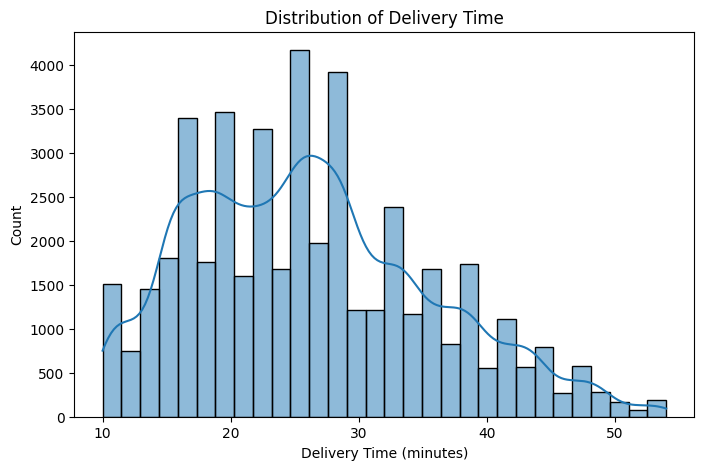

In [21]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=full_raw,
    x=TARGET_COLUMN,
    kde=True,
    bins=30
)
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Count")
plt.show()

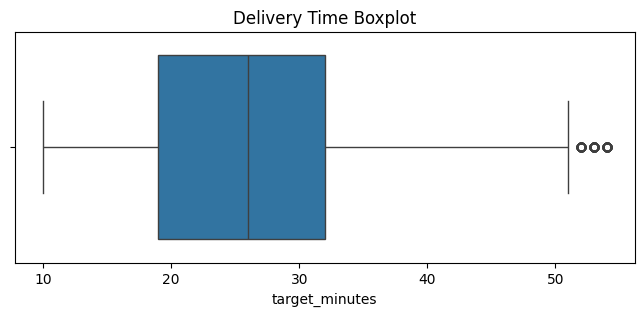

In [22]:
plt.figure(figsize=(8, 3))
sns.boxplot(
    data=full_raw,
    x=TARGET_COLUMN
)
plt.title("Delivery Time Boxplot")
plt.show()

The target variable, delivery time, shows a moderately right-skewed distribution rather than a perfectly normal distribution. Most deliveries are concentrated between approximately 20 and 35 minutes, with a median around 26 minutes. A small number of observations above 50 minutes are identified as potential outliers by the boxplot. However, these values remain plausible in the context of food delivery and were therefore retained for further analysis.

###6.2 Numeric Feature Distribution

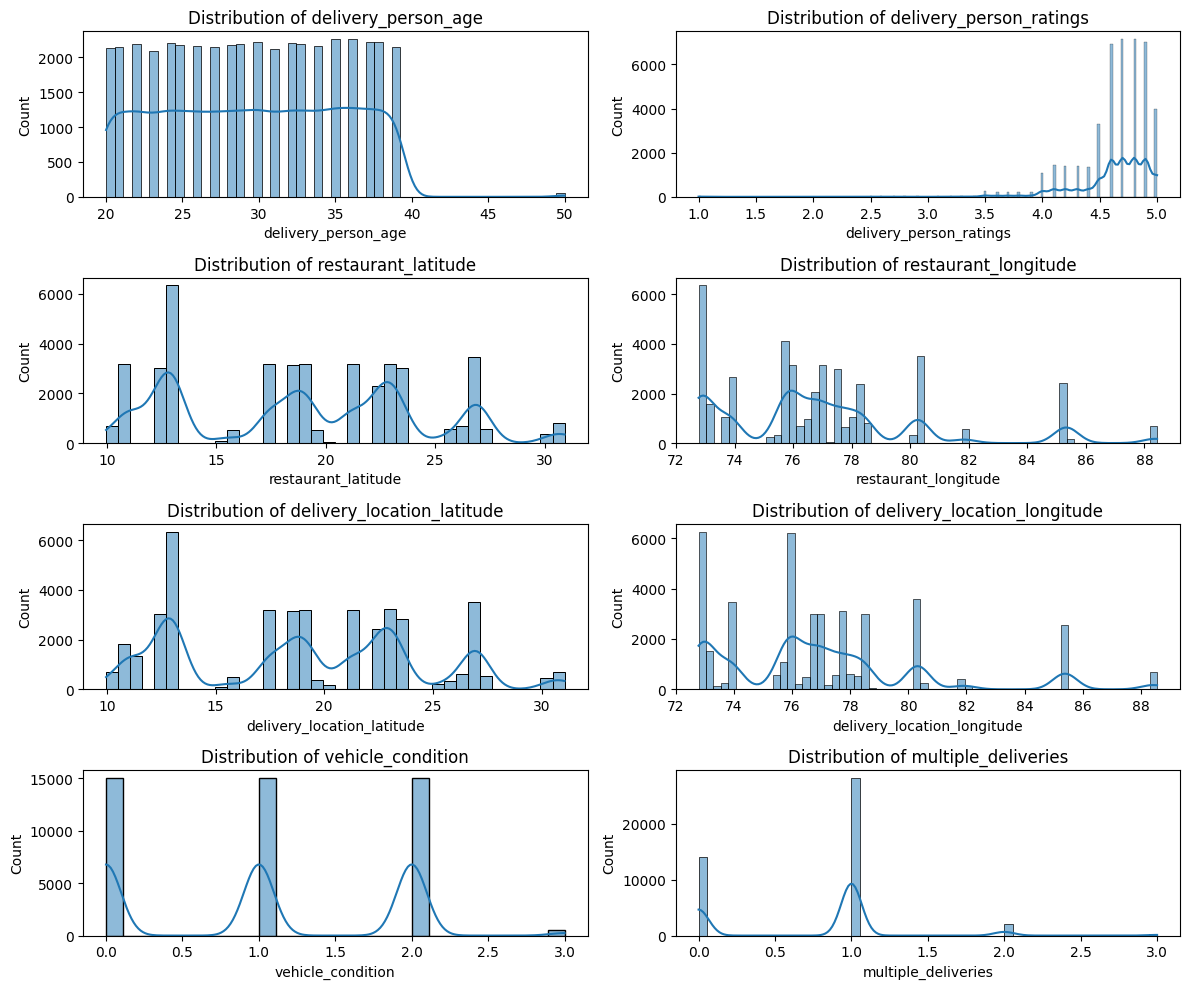

In [23]:
numeric_features = [
    "delivery_person_age",
    "delivery_person_ratings",
    "restaurant_latitude",
    "restaurant_longitude",
    "delivery_location_latitude",
    "delivery_location_longitude",
    "vehicle_condition",
    "multiple_deliveries",
]
fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(12, 10)
)

axes = axes.flatten()

for ax, column in zip(axes, numeric_features):
    sns.histplot(
        data=full_raw,
        x=column,
        kde=True,
        ax=ax
    )

    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

The numerical feature distributions reveal several distinct patterns. Delivery-person age is approximately uniformly distributed between the early 20s and late 30s, with very few extreme values. Delivery-person ratings are heavily concentrated between approximately 4.5 and 5.0, indicating that most delivery personnel have high ratings. The geographic coordinate variables show multiple distinct peaks, which likely reflect clusters of observations from different cities or service areas rather than a single continuous distribution. Vehicle condition takes only a small number of discrete values, suggesting that it should be treated as an ordinal or categorical feature rather than a continuous numerical variable. Similarly, the number of multiple deliveries is concentrated around 0 and 1, with relatively few observations at 2 or 3.

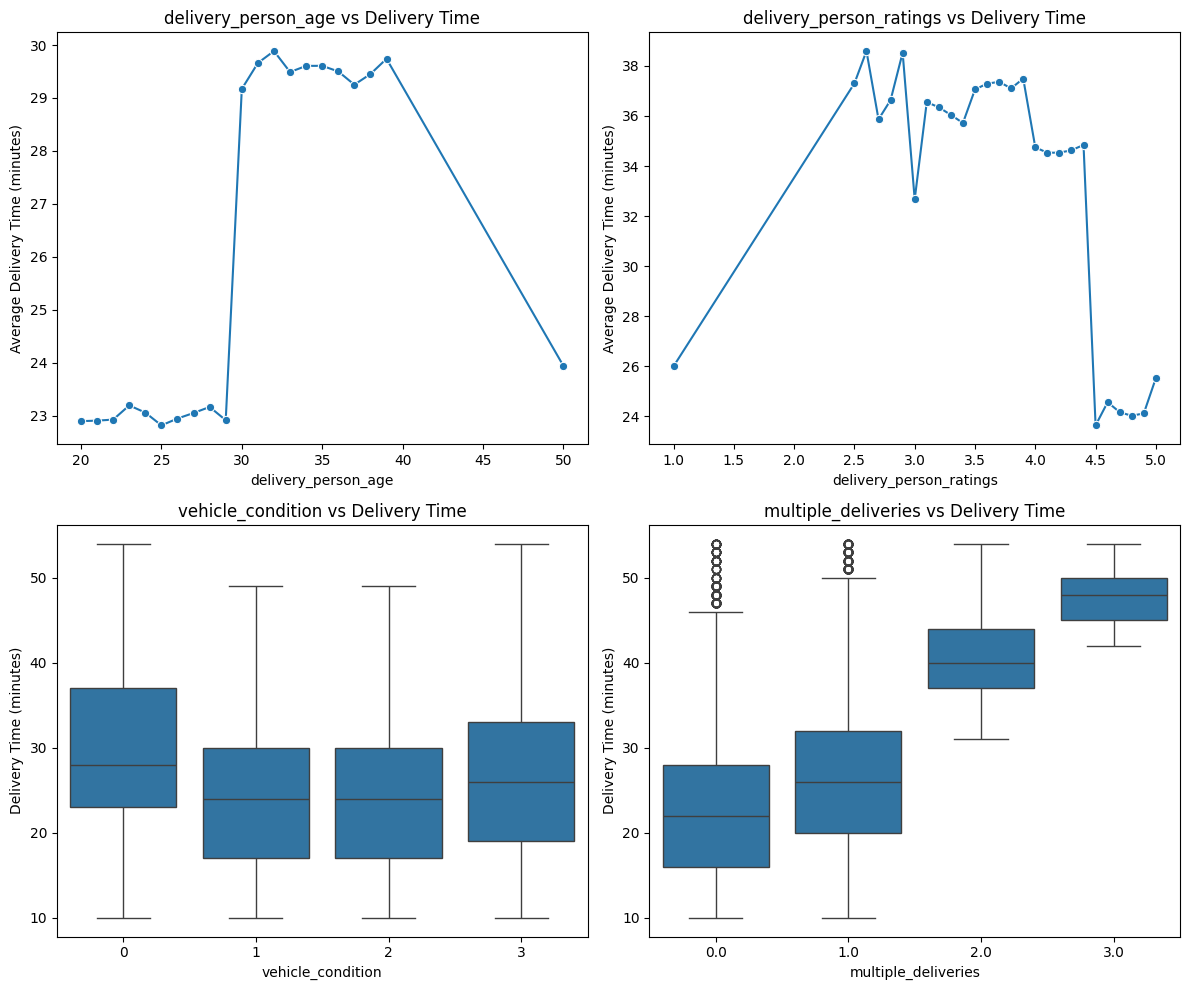

In [24]:
numeric_target_features = {
    "delivery_person_age": "discrete_numeric",
    "delivery_person_ratings": "discrete_numeric",
    "vehicle_condition": "ordinal",
    "multiple_deliveries": "ordinal"
}

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 10)
)

axes = axes.flatten()

for ax, (column, feature_type) in zip(
    axes,
    numeric_target_features.items()
):

    # Age and ratings:
    # Show average target for each observed feature value
    if feature_type == "discrete_numeric":

        summary = (
            full_raw
            .groupby(column, dropna=True)[TARGET_COLUMN]
            .mean()
            .reset_index()
        )

        sns.lineplot(
            data=summary,
            x=column,
            y=TARGET_COLUMN,
            marker="o",
            ax=ax
        )

        ax.set_ylabel("Average Delivery Time (minutes)")

    # Ordinal/discrete features:
    # Compare target distributions between levels
    elif feature_type == "ordinal":

        sns.boxplot(
            data=full_raw,
            x=column,
            y=TARGET_COLUMN,
            ax=ax
        )

        ax.set_ylabel("Delivery Time (minutes)")

    # Truly continuous variables:
    # Examine their relationship with target
    elif feature_type == "continuous":

        sns.scatterplot(
            data=full_raw,
            x=column,
            y=TARGET_COLUMN,
            alpha=0.15,
            s=15,
            ax=ax
        )

        ax.set_ylabel("Delivery Time (minutes)")

    ax.set_title(
        f"{column} vs Delivery Time"
    )

    ax.set_xlabel(column)


plt.tight_layout()
plt.show()

The relationship between the numerical features and delivery time shows several notable patterns. Delivery-person age appears to be associated with a marked increase in average delivery time around age 30, although this pattern should be interpreted cautiously and verified against the number of observations in each age group. Delivery-person ratings show a non-linear relationship with delivery time, with higher ratings, particularly above approximately 4.5, generally corresponding to shorter delivery times. Vehicle condition shows relatively modest differences across levels, although conditions 0 and 3 tend to have slightly higher delivery times. The strongest relationship is observed for multiple deliveries, where delivery time increases substantially as the number of concurrent deliveries rises, suggesting that this feature may be an important predictor of the target.

###6.3 Categorical Features

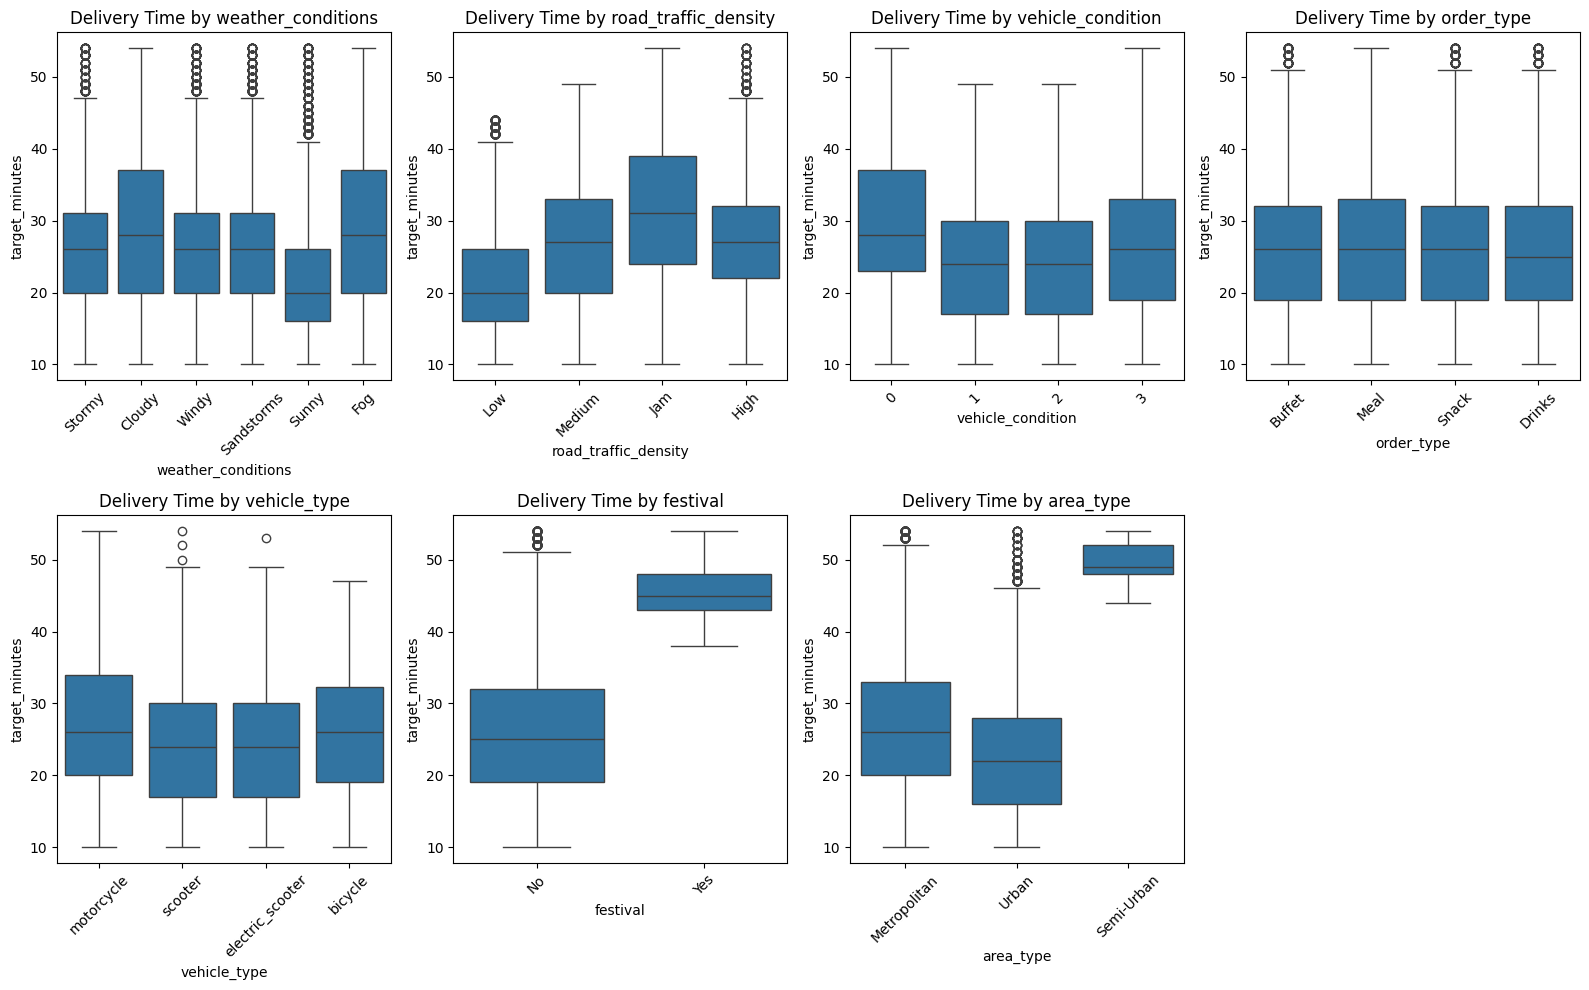

In [25]:
categorical_features = [
    "weather_conditions",
    "road_traffic_density",
    "vehicle_condition",
    "order_type",
    "vehicle_type",
    "festival",
    "area_type",
]

fig, axes = plt.subplots(
    2, 4,
    figsize=(16, 10)
)

axes = axes.flatten()

for ax, column in zip(axes, categorical_features):
    sns.boxplot(
        data=full_raw,
        x=column,
        y=TARGET_COLUMN,
        ax=ax
    )

    ax.set_title(f"Delivery Time by {column}")
    ax.tick_params(axis="x", rotation=45)


for ax in axes[len(categorical_features):]:
    ax.remove()

plt.tight_layout()
plt.show()

The categorical feature analysis reveals several meaningful relationships with delivery time. Road traffic density shows a clear upward pattern, with deliveries taking longer under medium, high, and especially jam traffic conditions compared with low traffic. Weather conditions also appear to influence delivery time, with cloudy and foggy conditions generally associated with longer deliveries, while sunny conditions tend to have shorter delivery times. Festival days show one of the strongest effects, with substantially higher delivery times compared with non-festival days. Area type is also highly informative, as semi-urban deliveries have much longer delivery times than metropolitan and urban deliveries. In contrast, order type shows very similar delivery-time distributions across categories, suggesting that it may have relatively limited predictive value. Vehicle type and vehicle condition show some differences, although their effects appear weaker than those of traffic, festival status, and area type.

In [26]:
for column in categorical_features:
  summary = (
        full_raw
        .groupby(column, dropna=False)[TARGET_COLUMN]
        .agg(["count", "mean", "median", "std"])
        .sort_values("mean", ascending=False)
    )

  display(summary)

,count,mean,median,std
weather_conditions,,,,
Cloudy,7533,28.917164,28.0,10.086234
Fog,7653,28.914674,28.0,10.129321
<NA>,616,26.545455,26.0,9.474890
Windy,7422,26.118836,26.0,8.615702
Sandstorms,7494,25.875500,26.0,8.619009
Stormy,7584,25.868803,26.0,8.473481
Sunny,7282,21.856770,20.0,8.328310


,count,mean,median,std
road_traffic_density,,,,
Jam,14139,31.176038,31.0,9.941898
High,4423,27.240109,27.0,8.397667
Medium,10945,26.699680,27.0,8.560638
<NA>,601,26.542429,26.0,9.456847
Low,15476,21.266671,20.0,6.799175


,count,mean,median,std
vehicle_condition,,,,
0,15005,30.073109,28.0,9.597452
3,520,26.492308,26.0,9.383703
2,15031,24.454394,24.0,8.641767
1,15028,24.353673,24.0,8.718856


,count,mean,median,std
order_type,,,,
Meal,11456,26.417598,26.0,9.424673
Snack,11530,26.285603,26.0,9.400074
Buffet,11277,26.283320,26.0,9.412183
Drinks,11321,26.187969,25.0,9.298875


,count,mean,median,std
vehicle_type,,,,
motorcycle,26429,27.605774,26.0,9.648667
bicycle,68,26.426471,26.0,9.262855
scooter,15273,24.478819,24.0,8.703799
electric_scooter,3814,24.470110,24.0,8.610859


,count,mean,median,std
festival,,,,
Yes,896,45.517857,45.0,4.001915
No,44460,25.984121,25.0,9.013540
<NA>,228,11.166667,11.0,1.234002


,count,mean,median,std
area_type,,,,
Semi-Urban,164,49.731707,49.0,2.693089
Metropolitan,34087,27.314460,26.0,9.184753
Urban,10133,22.983322,22.0,8.867217
<NA>,1200,22.058333,21.0,8.308577


The grouped summary statistics confirm the patterns observed in the boxplots. Traffic density, festival status, weather conditions, and area type show clear differences in delivery time. Deliveries under jam traffic conditions take substantially longer than those under low traffic, while festival days are associated with a particularly large increase in delivery time. Semi-urban areas also show much higher delivery times than metropolitan and urban areas, although this category contains relatively few observations. In contrast, order type shows almost no variation in mean or median delivery time across categories, suggesting limited predictive value. Vehicle type and vehicle condition show moderate differences and may still contribute useful information to the model.

###6.4 Correlation Matrix


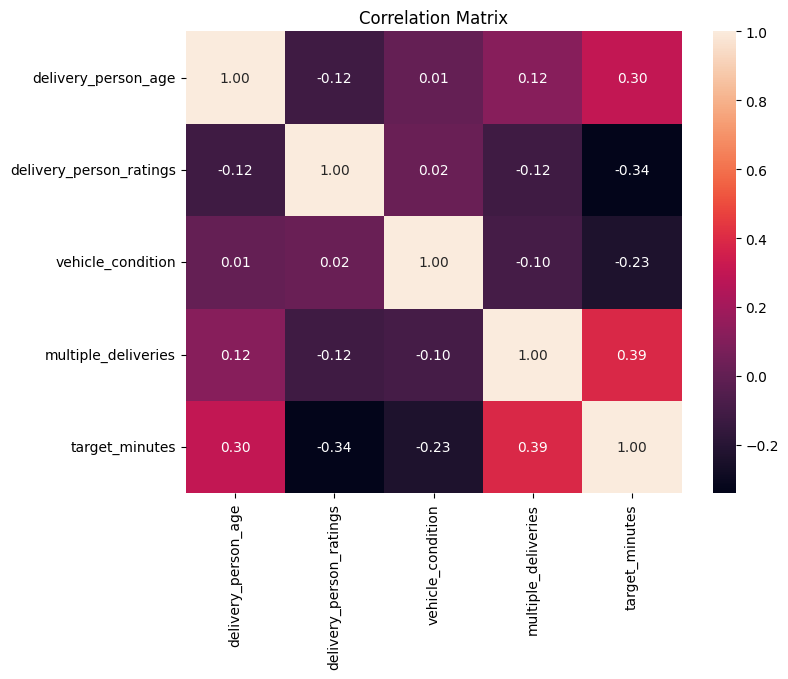

In [27]:
numeric_for_corr = [
    "delivery_person_age",
    "delivery_person_ratings",
    "vehicle_condition",
    "multiple_deliveries",
    TARGET_COLUMN,
]

corr_matrix = full_raw[numeric_for_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

The correlation analysis indicates that multiple_deliveries has the strongest positive linear relationship with delivery time (r = 0.39), suggesting that delivery duration tends to increase as the number of concurrent deliveries rises. Delivery-person ratings show a moderate negative correlation with the target (r = -0.34), indicating that higher-rated delivery personnel tend to have shorter delivery times. Delivery-person age has a moderate positive correlation with delivery time (r = 0.30), while vehicle condition shows a weaker negative relationship (r = -0.23). Correlations among the predictor variables are relatively low, suggesting no strong multicollinearity among these numerical features.

###6.5 Time-Based EDA


Failed date parses: 0


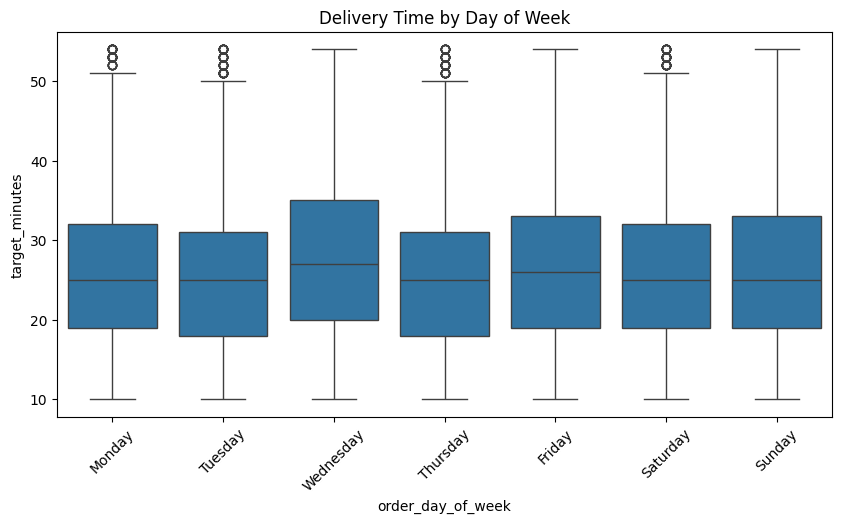

In [43]:

# Parse the date using the known dataset format
full_raw["order_date_parsed"] = pd.to_datetime(
    full_raw["order_date"],
    format="%d-%m-%Y",
    errors="coerce"
)

# Audit parsing success
date_parse_failed = (
    full_raw["order_date"].notna()
    & full_raw["order_date_parsed"].isna()
)

print("Failed date parses:", date_parse_failed.sum())

# Feature for EDA
full_raw["order_day_of_week"] = (
    full_raw["order_date_parsed"]
    .dt.day_name()
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=full_raw,
    x="order_day_of_week",
    y=TARGET_COLUMN,
    order=day_order
)
plt.xticks(rotation=45)
plt.title("Delivery Time by Day of Week")
plt.show()

Delivery-time distributions are broadly similar across the days of the week. Median delivery times remain close to approximately 25–27 minutes for most days, with substantial overlap between the distributions. Wednesday and Friday show slightly higher delivery times, but the overall differences are modest, suggesting that day of week may have limited predictive power on its own.

In [58]:
def parse_mixed_time_to_minutes(series: pd.Series) -> pd.Series:

    s = (
        series.astype("string")
        .str.strip()
    )

    result = pd.Series(
        np.nan,
        index=s.index,
        dtype="float64",
    )

    # HH:MM or HH:MM:SS
    colon_mask = s.str.contains(":", na=False)

    if colon_mask.any():

        parts = s.loc[colon_mask].str.split(
            ":",
            expand=True,
        )

        hours = pd.to_numeric(parts[0], errors="coerce")
        minutes = pd.to_numeric(parts[1], errors="coerce")

        if parts.shape[1] >= 3:
            seconds = (
                pd.to_numeric(parts[2], errors="coerce")
                .fillna(0)
            )
        else:
            seconds = pd.Series(
                0,
                index=parts.index,
            )

        result.loc[colon_mask] = (
            hours * 60
            + minutes
            + seconds / 60
        )

    # decimal day fractions
    numeric_mask = (
        ~colon_mask
        & s.notna()
    )

    if numeric_mask.any():

        fractions = pd.to_numeric(
            s.loc[numeric_mask],
            errors="coerce",
        )

        result.loc[numeric_mask] = (
            fractions * 24 * 60
        ).round()

    return result

Failed time parses: 0


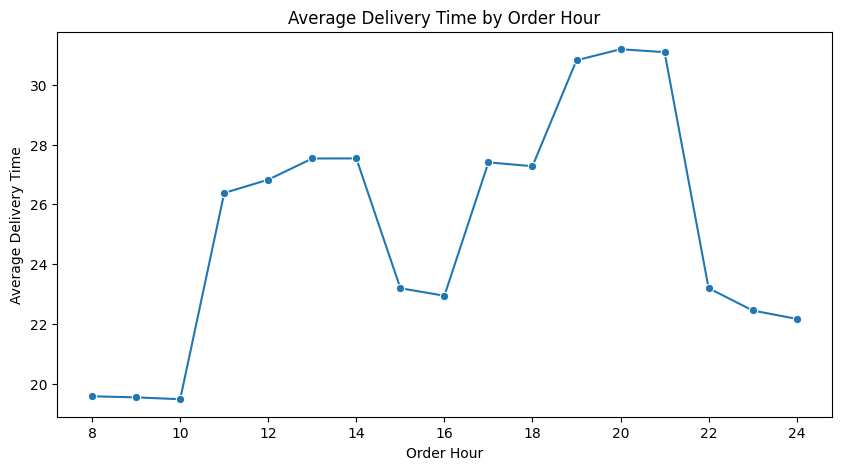

In [60]:
full_raw["order_minutes"] = parse_mixed_time_to_minutes(
    full_raw["time_ordered"]
)

time_parse_failed = (
    full_raw["time_ordered"].notna()
    & full_raw["order_minutes"].isna()
)

print("Failed time parses:", time_parse_failed.sum())

full_raw["order_hour"] = (
    full_raw["order_minutes"]
    .floordiv(60)
    .astype("Int64")
)
hourly_delivery = (
    full_raw
    .groupby("order_hour")[TARGET_COLUMN]
    .mean()
)

plt.figure(figsize=(10, 5))
sns.lineplot(
    x=hourly_delivery.index,
    y=hourly_delivery.values,
    marker="o"
)
plt.title("Average Delivery Time by Order Hour")
plt.xlabel("Order Hour")
plt.ylabel("Average Delivery Time")
plt.show()

Order hour shows a clear non-linear relationship with delivery time. Deliveries are fastest during the morning hours, while average delivery time increases around midday and reaches its highest level during the evening peak between approximately 19:00 and 21:00. Delivery times decrease again later at night. This pattern suggests that order hour captures meaningful peak-period effects and may be an important feature for prediction.

###6.6 Traffic + Weather

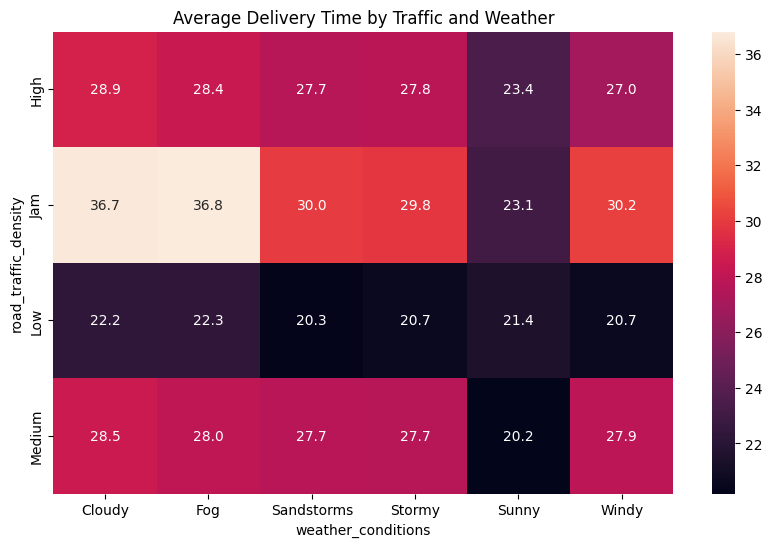

In [61]:
traffic_weather = (
    full_raw
    .groupby(
        ["road_traffic_density", "weather_conditions"]
    )[TARGET_COLUMN]
    .mean()
    .unstack()
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    traffic_weather,
    annot=True,
    fmt=".1f"
)
plt.title("Average Delivery Time by Traffic and Weather")
plt.show()

The interaction between traffic density and weather conditions reveals a clear combined effect on delivery time. Jam traffic is associated with the longest delivery times across most weather conditions, particularly under cloudy and foggy conditions, where average delivery time reaches approximately 37 minutes. In contrast, low traffic conditions result in substantially shorter delivery times regardless of weather. Sunny conditions generally correspond to lower delivery times across traffic levels. These results suggest that the effect of weather may depend on traffic conditions, indicating a potential interaction between the two features.

###6.7 Vehicle Type + Vehicle Condition

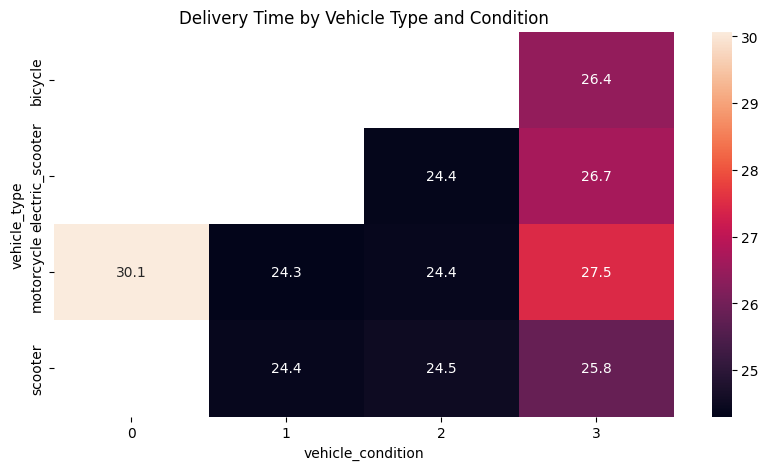

In [62]:
vehicle_summary = (
    full_raw
    .groupby(
        ["vehicle_type", "vehicle_condition"]
    )[TARGET_COLUMN]
    .mean()
    .unstack()
)

plt.figure(figsize=(10, 5))
sns.heatmap(
    vehicle_summary,
    annot=True,
    fmt=".1f"
)
plt.title("Delivery Time by Vehicle Type and Condition")
plt.show()

The interaction between vehicle type and vehicle condition shows that delivery time varies across specific vehicle-condition combinations. Motorcycles with vehicle condition 0 have the highest average delivery time, at approximately 30 minutes, whereas motorcycles with conditions 1 and 2 have substantially lower average delivery times of around 24 minutes. Scooter and electric scooter deliveries show very similar average times for conditions 1 and 2. Vehicle condition 3 is generally associated with somewhat higher delivery times across available vehicle types. However, some vehicle-condition combinations are absent from the dataset, so these patterns should be interpreted cautiously.

###6.8 Delivery Distance

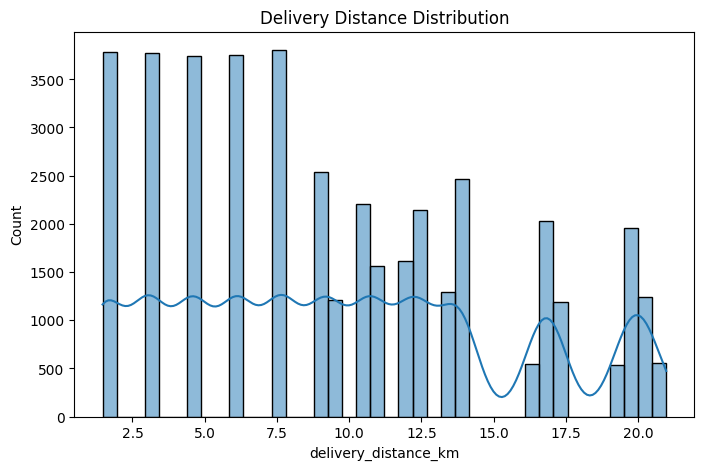

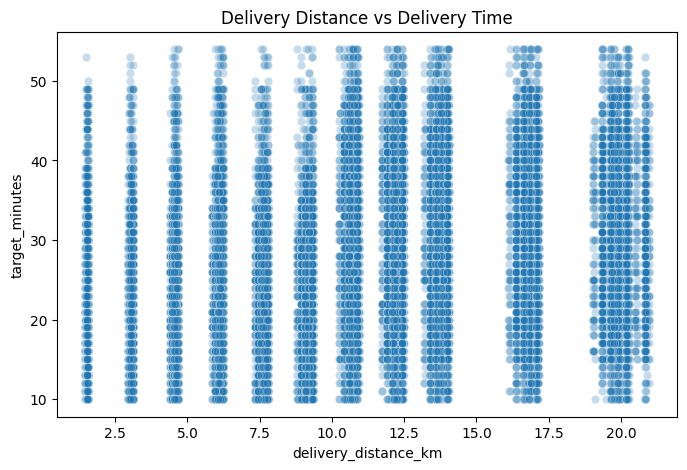

In [63]:
def haversine_distance(
    lat1,
    lon1,
    lat2,
    lon2
):
    radius_km = 6371.0

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return radius_km * c


full_raw["delivery_distance_km"] = haversine_distance(
    full_raw["restaurant_latitude"],
    full_raw["restaurant_longitude"],
    full_raw["delivery_location_latitude"],
    full_raw["delivery_location_longitude"],
)

plt.figure(figsize=(8, 5))
sns.histplot(
    data=full_raw,
    x="delivery_distance_km",
    bins=40,
    kde=True
)
plt.title("Delivery Distance Distribution")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=full_raw,
    x="delivery_distance_km",
    y=TARGET_COLUMN,
    alpha=0.25
)
plt.title("Delivery Distance vs Delivery Time")
plt.show()

The engineered delivery-distance feature shows a multimodal distribution, with observations concentrated around several recurring distance ranges. However, the scatterplot does not reveal a strong linear relationship between delivery distance and delivery time. Similar delivery distances are associated with a wide range of delivery durations, indicating that distance alone is insufficient to explain delivery time. This suggests that operational factors such as traffic density, weather conditions, festival status, and multiple deliveries may interact with distance and play an important role in determining delivery duration.


###6.9 Distance + Traffic

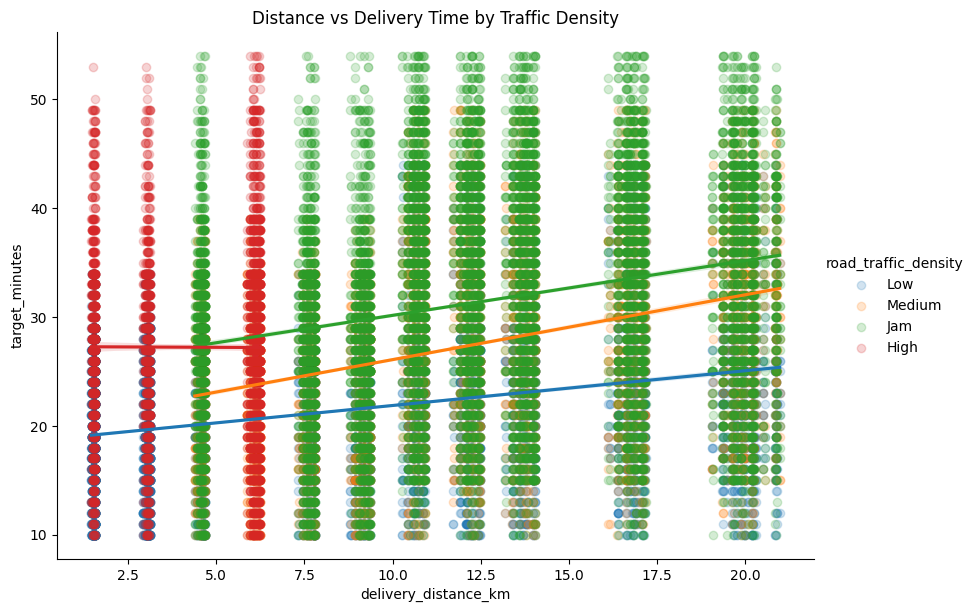

In [64]:
sns.lmplot(
    data=full_raw,
    x="delivery_distance_km",
    y=TARGET_COLUMN,
    hue="road_traffic_density",
    scatter_kws={"alpha": 0.2},
    height=6,
    aspect=1.4
)

plt.title("Distance vs Delivery Time by Traffic Density")
plt.show()

The relationship between delivery distance and delivery time varies across traffic-density levels. Under low traffic conditions, delivery time increases only gradually with distance, whereas the increase is more pronounced under medium and jam traffic conditions. Jam traffic is associated with consistently longer delivery times across the observed distance range. This suggests an interaction between delivery distance and traffic density, meaning that the effect of distance on delivery duration depends partly on traffic conditions.

###6.10 Target by Delivery Person

In [65]:
delivery_person_summary = (
    full_raw
    .groupby("delivery_person_id")[TARGET_COLUMN]
    .agg(["count", "mean"])
)

delivery_person_summary.describe()

,count,mean
count,1320.000000,1320.000000
mean,34.533333,26.347093
std,21.298993,1.938193
min,5.000000,19.444444
25%,13.000000,25.203409
50%,41.000000,26.278689
75%,56.000000,27.461538
max,67.000000,35.000000


The dataset contains 1,320 unique delivery personnel, with the number of recorded deliveries per person varying substantially from 5 to 67. However, average delivery times across delivery personnel are relatively concentrated, with a mean of approximately 26.3 minutes and a standard deviation of only 1.9 minutes. Most delivery personnel have average delivery times between approximately 25 and 27.5 minutes, suggesting that individual delivery-person identity may explain relatively limited variation in delivery time.

##7. Outlier Check


In [66]:
outlier_summary = []

for column in numeric_features + ["delivery_distance_km"]:

    # Original data remains unchanged.
    # Missing values are excluded only from the IQR calculation.
    non_missing_values = full_raw[column].dropna()

    q1 = non_missing_values.quantile(0.25)
    q3 = non_missing_values.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (
        (non_missing_values < lower_bound)
        | (non_missing_values > upper_bound)
    )

    outlier_count = outlier_mask.sum()

    outlier_summary.append({
        "feature": column,
        "outlier_count": int(outlier_count),
        "outlier_percent": (
            100 * outlier_count / len(non_missing_values)
        ),
        "missing_count": full_raw[column].isna().sum(),
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

,feature,outlier_count,outlier_percent,missing_count
0,delivery_person_age,0,0.000000,1892
1,delivery_person_ratings,1170,2.682071,1961
2,restaurant_latitude,0,0.000000,3640
3,restaurant_longitude,3263,7.779420,3640
4,delivery_location_latitude,0,0.000000,3640
5,delivery_location_longitude,3263,7.779420,3640
6,vehicle_condition,0,0.000000,0
7,multiple_deliveries,361,0.809580,993
8,delivery_distance_km,0,0.000000,3640


The IQR-based outlier analysis identified potential outliers in delivery-person ratings, longitude coordinates, and the number of multiple deliveries. However, these observations were not automatically removed. The longitude outliers likely reflect geographic variation across different service locations, while rare values in the multiple-deliveries feature may represent valid operational cases. Similarly, low delivery-person ratings may be uncommon but still valid. Therefore, the flagged observations were retained unless there was independent evidence that they represented data errors.

In [67]:
q1 = full_raw["delivery_person_ratings"].quantile(0.25)
q3 = full_raw["delivery_person_ratings"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print("Lower bound:", lower)
print("Upper bound:", upper)

print(
    full_raw.loc[
        (full_raw["delivery_person_ratings"] < lower)
        | (full_raw["delivery_person_ratings"] > upper),
        "delivery_person_ratings"
    ].value_counts().sort_index()
)

Lower bound: 3.8999999999999995
Upper bound: 5.500000000000001
delivery_person_ratings
1.0     38
2.5     20
2.6     22
2.7     22
2.8     19
2.9     19
3.0      6
3.1     29
3.2     29
3.3     25
3.4     32
3.5    249
3.6    207
3.7    225
3.8    228
Name: count, dtype: int64


The IQR method flagged ratings below approximately 3.9 as statistical outliers because the rating distribution is highly concentrated near the upper end of the scale. However, these lower ratings remain within the valid rating range and occur repeatedly in the dataset. Therefore, they were treated as rare but valid observations and were retained. Only the previously identified rating value of 6 was considered invalid and converted to missing.

#8. Train/Test Split


In [68]:
from sklearn.model_selection import train_test_split

X = full_raw.drop(columns=[TARGET_COLUMN])
y = full_raw[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (36467, 27)
X_test: (9117, 27)
y_train: (36467,)
y_test: (9117,)


In [73]:
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

##9. Feature Engineering


In [69]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36467 entries, 21963 to 15795
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   order_id                     36467 non-null  string        
 1   delivery_person_id           36467 non-null  string        
 2   delivery_person_age          34962 non-null  float64       
 3   delivery_person_ratings      34911 non-null  float64       
 4   restaurant_latitude          33570 non-null  float64       
 5   restaurant_longitude         33570 non-null  float64       
 6   delivery_location_latitude   33570 non-null  float64       
 7   delivery_location_longitude  33570 non-null  float64       
 8   order_date                   36467 non-null  datetime64[ns]
 9   time_ordered                 35080 non-null  string        
 10  time_order_picked            36467 non-null  string        
 11  weather_conditions           35974 non-nul

The delivery_distance_km, order_day_of_week and order_hour is already created in EDA steps. The order_day_of_week feature was not a fully effective feature but it may be interact with other features while modeling.


In [91]:
def engineer_features(
    df,
    include_pickup_delay=False
):
    """
    Create model-ready engineered features.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.

    include_pickup_delay : bool, default=False
        False:
            Primary model predicts delivery time using
            information available at order time.

        True:
            Secondary post-pickup experiment can use
            pickup delay information.
    """

    output = df.copy()

    # ==================================================
    # 1. DATE FEATURES
    # ==================================================

    # Parse date safely using the known dataset format
    output["order_date_parsed"] = pd.to_datetime(
        output["order_date"],
        format="%d-%m-%Y",
        errors="coerce"
    )

    # Day of week
    output["order_day_of_week"] = (
        output["order_date_parsed"]
        .dt.day_name()
        .astype("string")
    )

    # Weekend indicator
    output["is_weekend"] = (
        output["order_date_parsed"]
        .dt.dayofweek
        .isin([5, 6])
        .astype(int)
    )

    # ==================================================
    # 2. TIME FEATURES
    # ==================================================

    output["order_minutes"] = (
        parse_mixed_time_to_minutes(
            output["time_ordered"]
        )
    )

    # Convert times such as 24:10 back to the
    # 24-hour clock for time-of-day features
    minutes_in_day = (
        output["order_minutes"]
        % (24 * 60)
    )

    # Hour of day
    output["order_hour"] = (
        minutes_in_day
        .floordiv(60)
        .astype("float64")
    )

    # --------------------------------------------------
    # Cyclical encoding of time
    # --------------------------------------------------

    time_angle = (
        2
        * np.pi
        * minutes_in_day
        / (24 * 60)
    )

    output["order_time_sin"] = np.sin(
        time_angle
    )

    output["order_time_cos"] = np.cos(
        time_angle
    )

    # ==================================================
    # 3. OPTIONAL PICKUP DELAY
    # ==================================================
    #
    # Not used in the PRIMARY model because
    # time_order_picked is not known at order time.
    #
    # Can later be used for a secondary post-pickup
    # experiment.
    # ==================================================

    if include_pickup_delay:

        picked_minutes = (
            parse_mixed_time_to_minutes(
                output["time_order_picked"]
            )
        )

        pickup_delay = (
            picked_minutes
            - output["order_minutes"]
        )

        # Handle midnight crossing
        pickup_delay = pickup_delay.where(
            pickup_delay >= 0,
            pickup_delay + 24 * 60
        )

        output["pickup_delay_minutes"] = (
            pickup_delay
        )

    # ==================================================
    # 4. VEHICLE CONDITION AS CATEGORICAL
    # ==================================================

    if "vehicle_condition" in output.columns:

        output["vehicle_condition"] = (
            output["vehicle_condition"]
            .astype("string")
        )

    # ==================================================
    # 5. DROP RAW / REDUNDANT FEATURES
    # ==================================================

    columns_to_drop = [
        # Identifiers
        "order_id",
        "delivery_person_id",

        # Raw date/time columns
        "order_date",
        "time_ordered",
        "time_order_picked",

        # Intermediate engineered columns
        "order_date_parsed",
        "order_minutes",

        # Raw coordinates
        # delivery_distance_km already carries the
        # geographic information we want to model
        "restaurant_latitude",
        "restaurant_longitude",
        "delivery_location_latitude",
        "delivery_location_longitude",
    ]

    output = output.drop(
        columns=columns_to_drop,
        errors="ignore"
    )

    return output

In [92]:
X_train_fe = engineer_features(X_train,include_pickup_delay=False)
X_test_fe = engineer_features(X_test,include_pickup_delay=False)

print("Train after feature engineering:")
display(X_train_fe.info())

print("\nTest after feature engineering:")
display(X_test_fe.info())

Train after feature engineering:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36467 entries, 0 to 36466
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   delivery_person_age      34962 non-null  float64
 1   delivery_person_ratings  34911 non-null  float64
 2   weather_conditions       35974 non-null  string 
 3   road_traffic_density     35986 non-null  string 
 4   vehicle_condition        36467 non-null  string 
 5   order_type               36467 non-null  string 
 6   vehicle_type             36467 non-null  string 
 7   multiple_deliveries      35669 non-null  float64
 8   festival                 36288 non-null  string 
 9   area_type                35485 non-null  string 
 10  age_invalid              36467 non-null  int64  
 11  rating_invalid           36467 non-null  int64  
 12  coordinate_fixed         36467 non-null  int64  
 13  order_day_of_week        36467 non-null  st

None


Test after feature engineering:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9117 entries, 0 to 9116
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   delivery_person_age      8730 non-null   float64
 1   delivery_person_ratings  8712 non-null   float64
 2   weather_conditions       8994 non-null   string 
 3   road_traffic_density     8997 non-null   string 
 4   vehicle_condition        9117 non-null   string 
 5   order_type               9117 non-null   string 
 6   vehicle_type             9117 non-null   string 
 7   multiple_deliveries      8922 non-null   float64
 8   festival                 9068 non-null   string 
 9   area_type                8899 non-null   string 
 10  age_invalid              9117 non-null   int64  
 11  rating_invalid           9117 non-null   int64  
 12  coordinate_fixed         9117 non-null   int64  
 13  order_day_of_week        9117 non-null   stri

None

In [93]:
print("\nTrain shape:", X_train_fe.shape)
print("Test shape:", X_test_fe.shape)

print("\nTrain columns:")
print(X_train_fe.columns.tolist())

print("\nMissing values in train:")
display(
    X_train_fe
    .isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)


Train shape: (36467, 19)
Test shape: (9117, 19)

Train columns:
['delivery_person_age', 'delivery_person_ratings', 'weather_conditions', 'road_traffic_density', 'vehicle_condition', 'order_type', 'vehicle_type', 'multiple_deliveries', 'festival', 'area_type', 'age_invalid', 'rating_invalid', 'coordinate_fixed', 'order_day_of_week', 'order_hour', 'delivery_distance_km', 'is_weekend', 'order_time_sin', 'order_time_cos']

Missing values in train:


,missing_count
delivery_distance_km,2897
delivery_person_ratings,1556
delivery_person_age,1505
order_hour,1387
order_time_cos,1387
order_time_sin,1387
area_type,982
multiple_deliveries,798
weather_conditions,493
road_traffic_density,481


In [94]:
# --------------------------------------------------
# Feature engineering sanity checks
# --------------------------------------------------

assert X_train_fe.shape[1] == X_test_fe.shape[1]

assert list(X_train_fe.columns) == list(X_test_fe.columns)

# Raw identifiers should not reach the model
assert "order_id" not in X_train_fe.columns
assert "delivery_person_id" not in X_train_fe.columns

# Raw time/date variables should not reach the model
assert "order_date" not in X_train_fe.columns
assert "time_ordered" not in X_train_fe.columns
assert "time_order_picked" not in X_train_fe.columns

# Intermediate variables should not remain
assert "order_date_parsed" not in X_train_fe.columns
assert "order_minutes" not in X_train_fe.columns

# Pickup information should not exist in the primary model
assert "pickup_delay_minutes" not in X_train_fe.columns

# Train and test should contain exactly the same features
assert set(X_train_fe.columns) == set(X_test_fe.columns)

print("Feature engineering checks passed.")

Feature engineering checks passed.


In [95]:
print(
    "Train distance missing:",
    X_train_fe["delivery_distance_km"].isna().sum()
)

print(
    "Test distance missing:",
    X_test_fe["delivery_distance_km"].isna().sum()
)

print(
    "Total distance missing:",
    X_train_fe["delivery_distance_km"].isna().sum()
    + X_test_fe["delivery_distance_km"].isna().sum()
)

Train distance missing: 2897
Test distance missing: 743
Total distance missing: 3640


In [96]:
# ==================================================
# PREPROCESSING FEATURE GROUPS
# ==================================================

numeric_features = [
    "delivery_person_age",
    "delivery_person_ratings",
    "multiple_deliveries",
    "order_hour",
    "delivery_distance_km",
    "order_time_sin",
    "order_time_cos",
]

categorical_features = [
    "weather_conditions",
    "road_traffic_density",
    "vehicle_condition",
    "order_type",
    "vehicle_type",
    "festival",
    "area_type",
    "order_day_of_week",
]

binary_features = [
    "age_invalid",
    "rating_invalid",
    "coordinate_fixed",
    "is_weekend",
]
all_model_features = (
    numeric_features
    + categorical_features
    + binary_features
)

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Binary features:", len(binary_features))
print("Total features before encoding:", len(all_model_features))

Numeric features: 7
Categorical features: 8
Binary features: 4
Total features before encoding: 19


##10. Preprocessing Pipeline

In [97]:
numeric_pipeline_scaled = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
    ]
)

In [98]:
numeric_pipeline_tree = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True
            )
        ),
    ]
)

In [110]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                missing_values=pd.NA,
                strategy="constant",
                fill_value="__MISSING__"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        ),
    ]
)

In [111]:
preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline_scaled,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

In [112]:
preprocessor_tree = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline_tree,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

In [113]:
print("Scaled preprocessor:")
print(preprocessor_scaled)

print("\nTree preprocessor:")
print(preprocessor_tree)

Scaled preprocessor:
ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(add_indicator=True,
                                                                strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['delivery_person_age',
                                  'delivery_person_ratings',
                                  'multiple_deliveries', 'order_hour',
                                  'delivery_distance_km', 'order_time_sin',
                                  'order_time_cos']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImpute...
                                                                missing_values=<NA>,
                                             

In [114]:
print("Numeric dtypes:")
display(X_train_fe[numeric_features].dtypes)

print("\nCategorical dtypes:")
display(X_train_fe[categorical_features].dtypes)

print("\nBinary dtypes:")
display(X_train_fe[binary_features].dtypes)

Numeric dtypes:


,0
delivery_person_age,float64
delivery_person_ratings,float64
multiple_deliveries,float64
order_hour,float64
delivery_distance_km,float64
order_time_sin,float64
order_time_cos,float64



Categorical dtypes:


,0
weather_conditions,string[python]
road_traffic_density,string[python]
vehicle_condition,string[python]
order_type,string[python]
vehicle_type,string[python]
festival,string[python]
area_type,string[python]
order_day_of_week,string[python]



Binary dtypes:


,0
age_invalid,int64
rating_invalid,int64
coordinate_fixed,int64
is_weekend,int64


The features are divided into numerical, categorical, and binary groups so that each type can be processed appropriately. Missing numerical values are imputed using the median, while missing categorical values are retained as a separate category to preserve potentially informative missingness patterns. Categorical variables are one-hot encoded, and binary indicators are passed through without transformation. Two preprocessing configurations are created: one with standardized numerical features for scale-sensitive models such as linear regression, Ridge, and MLP, and another without scaling for tree-based models. All preprocessing steps will later be included within the modeling pipeline so that they are fitted independently within each cross-validation training fold, reducing the risk of data leakage.


##11. Baseline Model Evaluation with CV

###11.1 Cross-Validation Setup

In [115]:
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer


# ==================================================
# CROSS-VALIDATION SETUP
# ==================================================

N_SPLITS = 5

# Create target bins only for balancing CV folds.
# These bins are NOT used as model features.
cv_target_bins = pd.qcut(
    y_train,
    q=10,
    labels=False,
    duplicates="drop"
)

cv_splitter = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Store the exact folds so every model is evaluated
# on the same observations.
cv_splits = list(
    cv_splitter.split(
        X_train_fe,
        cv_target_bins
    )
)

print(f"Number of CV folds: {len(cv_splits)}")

for fold_number, (train_idx, valid_idx) in enumerate(
    cv_splits,
    start=1
):
    print(
        f"Fold {fold_number}: "
        f"train={len(train_idx)}, "
        f"validation={len(valid_idx)}"
    )

Number of CV folds: 5
Fold 1: train=29173, validation=7294
Fold 2: train=29173, validation=7294
Fold 3: train=29174, validation=7293
Fold 4: train=29174, validation=7293
Fold 5: train=29174, validation=7293


###11.2 Evaluation Metrics

In [116]:
# ==================================================
# EVALUATION METRICS
# ==================================================

def within_5_minutes(y_true, y_pred):
    """
    Proportion of predictions whose absolute error
    is at most 5 minutes.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    return np.mean(
        np.abs(y_true - y_pred) <= 5
    )


within_5_scorer = make_scorer(
    within_5_minutes,
    greater_is_better=True
)


scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
    "mape": "neg_mean_absolute_percentage_error",
    "within_5": within_5_scorer,
}

###11.3 Baseline Model

In [117]:
# ==================================================
# BASELINE MODEL PIPELINES
# ==================================================

baseline_models = {

    "Dummy Median": Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor_scaled)
            ),
            (
                "model",
                DummyRegressor(
                    strategy="median"
                )
            ),
        ]
    ),

    "Linear Regression": Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor_scaled)
            ),
            (
                "model",
                LinearRegression()
            ),
        ]
    ),

    "Ridge": Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor_scaled)
            ),
            (
                "model",
                Ridge(
                    alpha=1.0,
                    solver="lsqr"
                )
            ),
        ]
    ),
}

print(
    "Baseline models:",
    list(baseline_models.keys())
)

Baseline models: ['Dummy Median', 'Linear Regression', 'Ridge']


In [118]:
# ==================================================
# BASELINE CROSS-VALIDATION
# ==================================================

baseline_results = []

for model_name, pipeline in baseline_models.items():

    print(f"Evaluating: {model_name}")

    cv_result = cross_validate(
        estimator=pipeline,
        X=X_train_fe,
        y=y_train,
        cv=cv_splits,
        scoring=scoring,

        # Models are lightweight at this stage.
        # Avoid unnecessary nested parallelism.
        n_jobs=-1,

        return_train_score=False,
        error_score="raise"
    )

    baseline_results.append(
        {
            "model": model_name,

            "MAE_mean": (
                -cv_result["test_mae"].mean()
            ),

            "MAE_std": (
                cv_result["test_mae"].std(ddof=1)
            ),

            "RMSE_mean": (
                -cv_result["test_rmse"].mean()
            ),

            "RMSE_std": (
                cv_result["test_rmse"].std(ddof=1)
            ),

            "R2_mean": (
                cv_result["test_r2"].mean()
            ),

            "R2_std": (
                cv_result["test_r2"].std(ddof=1)
            ),

            "MAPE_pct": (
                -cv_result["test_mape"].mean()
                * 100
            ),

            "Within_5_min_pct": (
                cv_result["test_within_5"].mean()
                * 100
            ),

            "Fit_time_sec": (
                cv_result["fit_time"].mean()
            ),
        }
    )

Evaluating: Dummy Median
Evaluating: Linear Regression
Evaluating: Ridge


In [120]:
baseline_results_df = (
    pd.DataFrame(baseline_results)
    .sort_values("MAE_mean")
    .reset_index(drop=True)
)


baseline_summary = (
    baseline_results_df[
        [
            "model",
            "MAE_mean",
            "MAE_std",
            "RMSE_mean",
            "R2_mean",
            "MAPE_pct",
            "Within_5_min_pct",
        ]
    ]
    .copy()
)

baseline_summary.columns = [
    "Model",
    "CV MAE",
    "MAE Std",
    "CV RMSE",
    "CV R²",
    "CV MAPE (%)",
    "Within ±5 min (%)",
]

display(
    baseline_summary.round(3)
)

,Model,CV MAE,MAE Std,CV RMSE,CV R²,CV MAPE (%),Within ±5 min (%)
0,Linear Regression,4.722,0.045,5.906,0.606,20.807,59.931
1,Ridge,4.722,0.046,5.906,0.606,20.806,59.950
2,Dummy Median,7.588,0.013,9.497,-0.019,32.742,42.597


The baseline cross-validation results show that both Linear Regression and Ridge Regression substantially outperform the median Dummy Regressor. The mean absolute error decreases from 7.59 minutes for the dummy baseline to approximately 4.72 minutes for both linear models, corresponding to an improvement of about 38%. Similarly, RMSE decreases from 9.50 to 5.91 minutes, while the R² score increases to approximately 0.61. The percentage of predictions within ±5 minutes of the actual delivery time also improves from 42.6% to approximately 60%.

Linear Regression and Ridge Regression produce nearly identical results, suggesting that L2 regularization with the current configuration does not provide a meaningful improvement over ordinary least squares. The small standard deviation of MAE across the five folds indicates that the baseline performance is stable across different subsets of the training data. Overall, these results confirm that the engineered features contain meaningful predictive information, while also leaving substantial room for improvement through nonlinear models capable of capturing more complex relationships and feature interactions.


###11.4 Random Forest Baseline

In [122]:
from sklearn.ensemble import RandomForestRegressor

# ==================================================
# RANDOM FOREST BASELINE PIPELINE
# ==================================================

rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor_tree)
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        ),
    ]
)

print(rf_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(add_indicator=True,
                                                                                 strategy='median'))]),
                                                  ['delivery_person_age',
                                                   'delivery_person_ratings',
                                                   'multiple_deliveries',
                                                   'order_hour',
                                                   'delivery_distance_km',
                                                   'order_time_sin',
                                                   'order_time_cos']),
                                                 ('categorical',
                                                  Pi

In [123]:
# ==================================================
# RANDOM FOREST CROSS-VALIDATION
# ==================================================

print("Evaluating: Random Forest")

rf_cv_result = cross_validate(
    estimator=rf_pipeline,
    X=X_train_fe,
    y=y_train,
    cv=cv_splits,
    scoring=scoring,

    # RandomForest already uses all available cores
    n_jobs=1,

    return_train_score=True,
    error_score="raise"
)

Evaluating: Random Forest


In [124]:
rf_result = pd.DataFrame(
    {
        "Model": ["Random Forest"],

        "Train MAE": [
            -rf_cv_result["train_mae"].mean()
        ],

        "CV MAE": [
            -rf_cv_result["test_mae"].mean()
        ],

        "MAE Std": [
            rf_cv_result["test_mae"].std(ddof=1)
        ],

        "CV RMSE": [
            -rf_cv_result["test_rmse"].mean()
        ],

        "CV R²": [
            rf_cv_result["test_r2"].mean()
        ],

        "CV MAPE (%)": [
            -rf_cv_result["test_mape"].mean() * 100
        ],

        "Within ±5 min (%)": [
            rf_cv_result["test_within_5"].mean() * 100
        ],

        "Fit Time (sec)": [
            rf_cv_result["fit_time"].mean()
        ]
    }
)

display(
    rf_result.round(3)
)

,Model,Train MAE,CV MAE,MAE Std,CV RMSE,CV R²,CV MAPE (%),Within ±5 min (%),Fit Time (sec)
0,Random Forest,1.189,3.225,0.03,4.095,0.811,13.949,79.965,82.645


In [125]:
rf_comparison = pd.DataFrame(
    {
        "Model": ["Random Forest"],
        "CV MAE": [-rf_cv_result["test_mae"].mean()],
        "MAE Std": [rf_cv_result["test_mae"].std(ddof=1)],
        "CV RMSE": [-rf_cv_result["test_rmse"].mean()],
        "CV R²": [rf_cv_result["test_r2"].mean()],
        "CV MAPE (%)": [
            -rf_cv_result["test_mape"].mean() * 100
        ],
        "Within ±5 min (%)": [
            rf_cv_result["test_within_5"].mean() * 100
        ],
    }
)
model_comparison = pd.concat(
    [
        baseline_summary,
        rf_comparison
    ],
    ignore_index=True
)

model_comparison = (
    model_comparison
    .sort_values("CV MAE")
    .reset_index(drop=True)
)

display(
    model_comparison.round(3)
)

,Model,CV MAE,MAE Std,CV RMSE,CV R²,CV MAPE (%),Within ±5 min (%)
0,Random Forest,3.225,0.030,4.095,0.811,13.949,79.965
1,Linear Regression,4.722,0.045,5.906,0.606,20.807,59.931
2,Ridge,4.722,0.046,5.906,0.606,20.806,59.950
3,Dummy Median,7.588,0.013,9.497,-0.019,32.742,42.597


Random Forest substantially improves predictive performance compared with the linear baseline models. Its cross-validation MAE decreases to 3.23 minutes, compared with approximately 4.72 minutes for Linear Regression and Ridge Regression. RMSE also decreases to 4.10 minutes, while the R² score increases from approximately 0.61 to 0.81. In addition, nearly 80% of the predictions fall within ±5 minutes of the actual delivery time, compared with approximately 60% for the linear models. These results indicate that nonlinear relationships and feature interactions contribute substantially to delivery-time prediction.

However, the training MAE of 1.19 minutes is considerably lower than the cross-validation MAE of 3.23 minutes, indicating a noticeable degree of overfitting. Despite this train-validation gap, the low cross-validation MAE standard deviation suggests that validation performance is stable across folds. Therefore, Random Forest is a strong candidate, although regularization through hyperparameter tuning may be necessary to improve its generalization performance.


###11.5 LightGBM Baseline

In [127]:
from lightgbm import LGBMRegressor
# ==================================================
# LIGHTGBM BASELINE PIPELINE
# ==================================================

lgbm_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor_tree)
        ),
        (
            "model",
            LGBMRegressor(
                objective="regression",

                n_estimators=300,
                learning_rate=0.05,
                num_leaves=31,

                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        ),
    ]
)

print(lgbm_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(add_indicator=True,
                                                                                 strategy='median'))]),
                                                  ['delivery_person_age',
                                                   'delivery_person_ratings',
                                                   'multiple_deliveries',
                                                   'order_hour',
                                                   'delivery_distance_km',
                                                   'order_time_sin',
                                                   'order_time_cos']),
                                                 ('categorical',
                                                  Pi

In [128]:
# ==================================================
# LIGHTGBM CROSS-VALIDATION
# ==================================================

print("Evaluating: LightGBM")

lgbm_cv_result = cross_validate(
    estimator=lgbm_pipeline,
    X=X_train_fe,
    y=y_train,
    cv=cv_splits,
    scoring=scoring,

    # LightGBM itself already uses parallel threads
    n_jobs=1,

    return_train_score=True,
    error_score="raise"
)

Evaluating: LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006984 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 731
[LightGBM] [Info] Number of data points in the train set: 29173, number of used features: 56
[LightGBM] [Info] Start training from score 26.285229


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.074470 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 731
[LightGBM] [Info] Number of data points in the train set: 29173, number of used features: 56
[LightGBM] [Info] Start training from score 26.294416


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005128 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 731
[LightGBM] [Info] Number of data points in the train set: 29174, number of used features: 56
[LightGBM] [Info] Start training from score 26.288373


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005109 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 731
[LightGBM] [Info] Number of data points in the train set: 29174, number of used features: 56
[LightGBM] [Info] Start training from score 26.285254


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005164 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 731
[LightGBM] [Info] Number of data points in the train set: 29174, number of used features: 56
[LightGBM] [Info] Start training from score 26.293515


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [129]:
# ==================================================
# LIGHTGBM RESULTS
# ==================================================

lgbm_result = pd.DataFrame(
    {
        "Model": ["LightGBM"],

        "Train MAE": [
            -lgbm_cv_result["train_mae"].mean()
        ],

        "CV MAE": [
            -lgbm_cv_result["test_mae"].mean()
        ],

        "MAE Std": [
            lgbm_cv_result["test_mae"].std(ddof=1)
        ],

        "CV RMSE": [
            -lgbm_cv_result["test_rmse"].mean()
        ],

        "CV R²": [
            lgbm_cv_result["test_r2"].mean()
        ],

        "CV MAPE (%)": [
            -lgbm_cv_result["test_mape"].mean()
            * 100
        ],

        "Within ±5 min (%)": [
            lgbm_cv_result["test_within_5"].mean()
            * 100
        ],

        "Fit Time (sec)": [
            lgbm_cv_result["fit_time"].mean()
        ]
    }
)

display(
    lgbm_result.round(3)
)

,Model,Train MAE,CV MAE,MAE Std,CV RMSE,CV R²,CV MAPE (%),Within ±5 min (%),Fit Time (sec)
0,LightGBM,2.997,3.184,0.029,4.014,0.818,13.787,80.152,1.689


In [131]:
lgbm_comparison = pd.DataFrame(
    {
        "Model": ["LightGBM"],

        "CV MAE": [
            -lgbm_cv_result["test_mae"].mean()
        ],

        "MAE Std": [
            lgbm_cv_result["test_mae"].std(ddof=1)
        ],

        "CV RMSE": [
            -lgbm_cv_result["test_rmse"].mean()
        ],

        "CV R²": [
            lgbm_cv_result["test_r2"].mean()
        ],

        "CV MAPE (%)": [
            -lgbm_cv_result["test_mape"].mean()
            * 100
        ],

        "Within ±5 min (%)": [
            lgbm_cv_result["test_within_5"].mean()
            * 100
        ],
    }
)

In [132]:
model_comparison_with_lgbm = pd.concat(
    [
        model_comparison,
        lgbm_comparison
    ],
    ignore_index=True
)

model_comparison_with_lgbm = (
    model_comparison_with_lgbm
    .sort_values("CV MAE")
    .reset_index(drop=True)
)

display(
    model_comparison_with_lgbm.round(3)
)

,Model,CV MAE,MAE Std,CV RMSE,CV R²,CV MAPE (%),Within ±5 min (%)
0,LightGBM,3.184,0.029,4.014,0.818,13.787,80.152
1,Random Forest,3.225,0.030,4.095,0.811,13.949,79.965
2,Linear Regression,4.722,0.045,5.906,0.606,20.807,59.931
3,Ridge,4.722,0.046,5.906,0.606,20.806,59.950
4,Dummy Median,7.588,0.013,9.497,-0.019,32.742,42.597


In [133]:
lgbm_fold_results = pd.DataFrame(
    {
        "Fold": np.arange(
            1,
            len(cv_splits) + 1
        ),

        "Train MAE": (
            -lgbm_cv_result["train_mae"]
        ),

        "Validation MAE": (
            -lgbm_cv_result["test_mae"]
        ),

        "Validation RMSE": (
            -lgbm_cv_result["test_rmse"]
        ),

        "Validation R²": (
            lgbm_cv_result["test_r2"]
        ),
    }
)

display(
    lgbm_fold_results.round(3)
)

,Fold,Train MAE,Validation MAE,Validation RMSE,Validation R²
0,1,2.979,3.224,4.053,0.814
1,2,2.999,3.153,3.956,0.823
2,3,3.003,3.181,4.013,0.819
3,4,3.000,3.159,3.986,0.821
4,5,3.002,3.201,4.061,0.813


LightGBM achieved the best cross-validation performance among the models evaluated so far, with an MAE of 3.18 minutes, RMSE of 4.01 minutes, and R² of 0.82. Although its improvement over Random Forest in validation error was relatively small, LightGBM exhibited a substantially smaller gap between training and validation MAE, suggesting better generalization and considerably less overfitting. Performance was also highly consistent across the five validation folds. In addition, LightGBM required substantially less training time than Random Forest, making it a promising candidate for subsequent hyperparameter optimization.

###11.6 XGBoost Baseline

In [135]:
from xgboost import XGBRegressor
# ==================================================
# XGBOOST BASELINE PIPELINE
# ==================================================

xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor_tree)
        ),
        (
            "model",
            XGBRegressor(
                objective="reg:squarederror",

                n_estimators=300,
                learning_rate=0.05,
                max_depth=6,

                subsample=0.9,
                colsample_bytree=0.9,

                tree_method="hist",

                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        ),
    ]
)

print(xgb_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(add_indicator=True,
                                                                                 strategy='median'))]),
                                                  ['delivery_person_age',
                                                   'delivery_person_ratings',
                                                   'multiple_deliveries',
                                                   'order_hour',
                                                   'delivery_distance_km',
                                                   'order_time_sin',
                                                   'order_time_cos']),
                                                 ('categorical',
                                                  Pi

In [137]:
# ==================================================
# XGBOOST CROSS-VALIDATION
# ==================================================

print("Evaluating: XGBoost")

xgb_cv_result = cross_validate(
    estimator=xgb_pipeline,
    X=X_train_fe,
    y=y_train,
    cv=cv_splits,
    scoring=scoring,

    # XGBoost already uses multiple threads internally
    n_jobs=1,

    return_train_score=True,
    error_score="raise"
)

Evaluating: XGBoost


In [138]:
# ==================================================
# XGBOOST RESULTS
# ==================================================

xgb_result = pd.DataFrame(
    {
        "Model": ["XGBoost"],

        "Train MAE": [
            -xgb_cv_result["train_mae"].mean()
        ],

        "CV MAE": [
            -xgb_cv_result["test_mae"].mean()
        ],

        "MAE Std": [
            xgb_cv_result["test_mae"].std(ddof=1)
        ],

        "CV RMSE": [
            -xgb_cv_result["test_rmse"].mean()
        ],

        "CV R²": [
            xgb_cv_result["test_r2"].mean()
        ],

        "CV MAPE (%)": [
            -xgb_cv_result["test_mape"].mean()
            * 100
        ],

        "Within ±5 min (%)": [
            xgb_cv_result["test_within_5"].mean()
            * 100
        ],

        "Fit Time (sec)": [
            xgb_cv_result["fit_time"].mean()
        ]
    }
)

display(
    xgb_result.round(3)
)

,Model,Train MAE,CV MAE,MAE Std,CV RMSE,CV R²,CV MAPE (%),Within ±5 min (%),Fit Time (sec)
0,XGBoost,2.925,3.21,0.032,4.043,0.815,13.908,79.848,2.98


In [139]:
xgb_fold_results = pd.DataFrame(
    {
        "Fold": np.arange(
            1,
            len(cv_splits) + 1
        ),

        "Train MAE": (
            -xgb_cv_result["train_mae"]
        ),

        "Validation MAE": (
            -xgb_cv_result["test_mae"]
        ),

        "Validation RMSE": (
            -xgb_cv_result["test_rmse"]
        ),

        "Validation R²": (
            xgb_cv_result["test_r2"]
        ),
    }
)

display(
    xgb_fold_results.round(3)
)

,Fold,Train MAE,Validation MAE,Validation RMSE,Validation R²
0,1,2.913,3.253,4.077,0.812
1,2,2.935,3.186,4.012,0.818
2,3,2.923,3.187,4.012,0.819
3,4,2.928,3.188,4.018,0.818
4,5,2.925,3.236,4.098,0.809


In [141]:
xgb_comparison = pd.DataFrame(
    {
        "Model": ["XGBoost"],

        "CV MAE": [
            -xgb_cv_result["test_mae"].mean()
        ],

        "MAE Std": [
            xgb_cv_result["test_mae"].std(ddof=1)
        ],

        "CV RMSE": [
            -xgb_cv_result["test_rmse"].mean()
        ],

        "CV R²": [
            xgb_cv_result["test_r2"].mean()
        ],

        "CV MAPE (%)": [
            -xgb_cv_result["test_mape"].mean()
            * 100
        ],

        "Within ±5 min (%)": [
            xgb_cv_result["test_within_5"].mean()
            * 100
        ],
    }
)
model_comparison_with_xgb = pd.concat(
    [
        model_comparison_with_lgbm,
        xgb_comparison
    ],
    ignore_index=True
)

model_comparison_with_xgb = (
    model_comparison_with_xgb
    .sort_values("CV MAE")
    .reset_index(drop=True)
)

display(
    model_comparison_with_xgb.round(3)
)

,Model,CV MAE,MAE Std,CV RMSE,CV R²,CV MAPE (%),Within ±5 min (%)
0,LightGBM,3.184,0.029,4.014,0.818,13.787,80.152
1,XGBoost,3.210,0.032,4.043,0.815,13.908,79.848
2,Random Forest,3.225,0.030,4.095,0.811,13.949,79.965
3,Linear Regression,4.722,0.045,5.906,0.606,20.807,59.931
4,Ridge,4.722,0.046,5.906,0.606,20.806,59.950
5,Dummy Median,7.588,0.013,9.497,-0.019,32.742,42.597


XGBoost achieved strong and stable cross-validation performance, with a mean absolute error of 3.21 minutes, RMSE of 4.04 minutes, and R² of approximately 0.82. Its training MAE of 2.93 minutes is relatively close to the cross-validation MAE, indicating substantially less overfitting than the Random Forest model. Performance was also consistent across all five folds, with a low MAE standard deviation of 0.032.

XGBoost slightly underperformed LightGBM across the main validation metrics, although the difference in MAE was small. Both boosting models therefore appear to be strong candidates for subsequent hyperparameter optimization. Their performance also confirms that nonlinear models are better suited to capturing the complex relationships and interactions observed in the exploratory analysis than the linear baseline models.


###11.7 CatBoost Baseline

In [143]:
!pip -q install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.5 MB/s eta 0:00:00


In [144]:
from catboost import CatBoostRegressor
from sklearn.preprocessing import FunctionTransformer
# ==================================================
# CATBOOST-SPECIFIC PREPROCESSING
# ==================================================

def prepare_for_catboost(X):
    """
    Prepare the engineered dataframe for CatBoost.

    - Numerical missing values are kept as NaN so that
      CatBoost can handle them natively.
    - Missing categorical values are represented by a
      dedicated string category.
    - Column names and DataFrame structure are preserved.
    """

    X = X.copy()

    # Categorical features
    for column in categorical_features:

        X[column] = (
            X[column]
            .astype("string")
            .fillna("__MISSING__")
            .astype(str)
        )

    # Numerical + binary features
    for column in numeric_features + binary_features:

        X[column] = pd.to_numeric(
            X[column],
            errors="coerce"
        ).astype("float64")

    return X


catboost_preprocessor = FunctionTransformer(
    prepare_for_catboost,
    validate=False,
    feature_names_out="one-to-one"
)

In [145]:
catboost_sample = prepare_for_catboost(
    X_train_fe.head(1000)
)

print(catboost_sample.dtypes)

print(
    "\nCategorical missing values:",
    catboost_sample[categorical_features]
    .isna()
    .sum()
    .sum()
)

print(
    "Numeric missing values:",
    catboost_sample[numeric_features]
    .isna()
    .sum()
    .sum()
)

delivery_person_age        float64
delivery_person_ratings    float64
weather_conditions          object
road_traffic_density        object
vehicle_condition           object
order_type                  object
vehicle_type                object
multiple_deliveries        float64
festival                    object
area_type                   object
age_invalid                float64
rating_invalid             float64
coordinate_fixed           float64
order_day_of_week           object
order_hour                 float64
delivery_distance_km       float64
is_weekend                 float64
order_time_sin             float64
order_time_cos             float64
dtype: object

Categorical missing values: 0
Numeric missing values: 272


In [148]:
# ==================================================
# CATBOOST MANUAL CROSS-VALIDATION
# ==================================================

from catboost import CatBoostRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)
import time

print("Evaluating: CatBoost")

catboost_train_mae = []
catboost_valid_mae = []
catboost_valid_rmse = []
catboost_valid_r2 = []
catboost_valid_mape = []
catboost_valid_within5 = []
catboost_fit_times = []

for fold, (train_idx, valid_idx) in enumerate(
    cv_splits,
    start=1
):

    # ----------------------------------------------
    # Split the fold
    # ----------------------------------------------

    X_fold_train = X_train_fe.iloc[train_idx].copy()
    X_fold_valid = X_train_fe.iloc[valid_idx].copy()

    y_fold_train = y_train.iloc[train_idx]
    y_fold_valid = y_train.iloc[valid_idx]

    # ----------------------------------------------
    # CatBoost-specific preprocessing
    # ----------------------------------------------

    X_fold_train_cb = prepare_for_catboost(
        X_fold_train
    )

    X_fold_valid_cb = prepare_for_catboost(
        X_fold_valid
    )

    # ----------------------------------------------
    # Define a fresh model for each fold
    # ----------------------------------------------

    model = CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=7,

        loss_function="RMSE",

        random_seed=RANDOM_STATE,

        verbose=0,
        allow_writing_files=False,

        thread_count=-1
    )

    # ----------------------------------------------
    # Fit
    # ----------------------------------------------

    start_time = time.time()

    model.fit(
        X_fold_train_cb,
        y_fold_train,

        cat_features=categorical_features,

        verbose=False
    )

    fit_time = time.time() - start_time

    # ----------------------------------------------
    # Predictions
    # ----------------------------------------------

    train_pred = model.predict(
        X_fold_train_cb
    )

    valid_pred = model.predict(
        X_fold_valid_cb
    )

    # ----------------------------------------------
    # Metrics
    # ----------------------------------------------

    train_mae = mean_absolute_error(
        y_fold_train,
        train_pred
    )

    valid_mae = mean_absolute_error(
        y_fold_valid,
        valid_pred
    )

    valid_rmse = np.sqrt(
        mean_squared_error(
            y_fold_valid,
            valid_pred
        )
    )

    valid_r2 = r2_score(
        y_fold_valid,
        valid_pred
    )

    valid_mape = mean_absolute_percentage_error(
        y_fold_valid,
        valid_pred
    )

    valid_within5 = np.mean(
        np.abs(
            np.asarray(y_fold_valid)
            - valid_pred
        ) <= 5
    )

    # ----------------------------------------------
    # Store results
    # ----------------------------------------------

    catboost_train_mae.append(train_mae)
    catboost_valid_mae.append(valid_mae)
    catboost_valid_rmse.append(valid_rmse)
    catboost_valid_r2.append(valid_r2)
    catboost_valid_mape.append(valid_mape)
    catboost_valid_within5.append(valid_within5)
    catboost_fit_times.append(fit_time)

    print(
        f"Fold {fold}: "
        f"Train MAE={train_mae:.3f}, "
        f"Validation MAE={valid_mae:.3f}"
    )

Evaluating: CatBoost
Fold 1: Train MAE=3.079, Validation MAE=3.207
Fold 2: Train MAE=3.086, Validation MAE=3.120
Fold 3: Train MAE=3.080, Validation MAE=3.140
Fold 4: Train MAE=3.095, Validation MAE=3.137
Fold 5: Train MAE=3.074, Validation MAE=3.148


In [149]:
# ==================================================
# STORE CATBOOST RESULTS IN THE SAME FORMAT
# ==================================================

catboost_cv_result = {
    "train_mae": -np.array(
        catboost_train_mae
    ),

    "test_mae": -np.array(
        catboost_valid_mae
    ),

    "test_rmse": -np.array(
        catboost_valid_rmse
    ),

    "test_r2": np.array(
        catboost_valid_r2
    ),

    "test_mape": -np.array(
        catboost_valid_mape
    ),

    "test_within_5": np.array(
        catboost_valid_within5
    ),

    "fit_time": np.array(
        catboost_fit_times
    )
}

print("\nCatBoost cross-validation completed.")


CatBoost cross-validation completed.


In [150]:
catboost_result = pd.DataFrame(
    {
        "Model": ["CatBoost"],

        "Train MAE": [
            -catboost_cv_result["train_mae"].mean()
        ],

        "CV MAE": [
            -catboost_cv_result["test_mae"].mean()
        ],

        "MAE Std": [
            catboost_cv_result["test_mae"].std(ddof=1)
        ],

        "CV RMSE": [
            -catboost_cv_result["test_rmse"].mean()
        ],

        "CV R²": [
            catboost_cv_result["test_r2"].mean()
        ],

        "CV MAPE (%)": [
            -catboost_cv_result["test_mape"].mean()
            * 100
        ],

        "Within ±5 min (%)": [
            catboost_cv_result["test_within_5"].mean()
            * 100
        ],

        "Fit Time (sec)": [
            catboost_cv_result["fit_time"].mean()
        ],
    }
)

display(
    catboost_result.round(3)
)

,Model,Train MAE,CV MAE,MAE Std,CV RMSE,CV R²,CV MAPE (%),Within ±5 min (%),Fit Time (sec)
0,CatBoost,3.083,3.15,0.033,3.968,0.822,13.615,80.75,35.14


In [151]:
catboost_fold_results = pd.DataFrame(
    {
        "Fold": np.arange(
            1,
            len(cv_splits) + 1
        ),

        "Train MAE": (
            -catboost_cv_result["train_mae"]
        ),

        "Validation MAE": (
            -catboost_cv_result["test_mae"]
        ),

        "Validation RMSE": (
            -catboost_cv_result["test_rmse"]
        ),

        "Validation R²": (
            catboost_cv_result["test_r2"]
        ),
    }
)

display(
    catboost_fold_results.round(3)
)

,Fold,Train MAE,Validation MAE,Validation RMSE,Validation R²
0,1,3.079,3.207,4.018,0.817
1,2,3.086,3.120,3.933,0.825
2,3,3.080,3.140,3.941,0.826
3,4,3.095,3.137,3.955,0.824
4,5,3.074,3.148,3.993,0.819


In [152]:
# ==================================================
# ADD CATBOOST TO MODEL COMPARISON
# ==================================================

catboost_comparison = pd.DataFrame(
    {
        "Model": ["CatBoost"],

        "CV MAE": [
            -catboost_cv_result["test_mae"].mean()
        ],

        "MAE Std": [
            catboost_cv_result["test_mae"].std(ddof=1)
        ],

        "CV RMSE": [
            -catboost_cv_result["test_rmse"].mean()
        ],

        "CV R²": [
            catboost_cv_result["test_r2"].mean()
        ],

        "CV MAPE (%)": [
            -catboost_cv_result["test_mape"].mean() * 100
        ],

        "Within ±5 min (%)": [
            catboost_cv_result["test_within_5"].mean() * 100
        ],
    }
)

model_comparison_all = pd.concat(
    [
        model_comparison_with_xgb,
        catboost_comparison
    ],
    ignore_index=True
)

model_comparison_all = (
    model_comparison_all
    .sort_values("CV MAE")
    .reset_index(drop=True)
)

display(
    model_comparison_all.round(3)
)

,Model,CV MAE,MAE Std,CV RMSE,CV R²,CV MAPE (%),Within ±5 min (%)
0,CatBoost,3.150,0.033,3.968,0.822,13.615,80.750
1,LightGBM,3.184,0.029,4.014,0.818,13.787,80.152
2,XGBoost,3.210,0.032,4.043,0.815,13.908,79.848
3,Random Forest,3.225,0.030,4.095,0.811,13.949,79.965
4,Linear Regression,4.722,0.045,5.906,0.606,20.807,59.931
5,Ridge,4.722,0.046,5.906,0.606,20.806,59.950
6,Dummy Median,7.588,0.013,9.497,-0.019,32.742,42.597


CatBoost achieved the strongest baseline performance among the evaluated models, obtaining a cross-validation MAE of 3.15 minutes, RMSE of 3.97 minutes, and R² of 0.82. It also achieved the highest proportion of predictions within ±5 minutes of the actual delivery time at approximately 80.8%. Although the improvement over LightGBM and XGBoost was relatively small, CatBoost showed the smallest gap between training and validation MAE, indicating strong generalization with limited evidence of overfitting. These results make CatBoost, LightGBM, and XGBoost the strongest candidates for subsequent hyperparameter optimization.

In [153]:
advanced_model_diagnostics = pd.DataFrame(
    {
        "Model": [
            "Random Forest",
            "LightGBM",
            "XGBoost",
            "CatBoost"
        ],

        "Train MAE": [
            -rf_cv_result["train_mae"].mean(),
            -lgbm_cv_result["train_mae"].mean(),
            -xgb_cv_result["train_mae"].mean(),
            -catboost_cv_result["train_mae"].mean(),
        ],

        "CV MAE": [
            -rf_cv_result["test_mae"].mean(),
            -lgbm_cv_result["test_mae"].mean(),
            -xgb_cv_result["test_mae"].mean(),
            -catboost_cv_result["test_mae"].mean(),
        ],
    }
)

advanced_model_diagnostics["Train-CV Gap"] = (
    advanced_model_diagnostics["CV MAE"]
    - advanced_model_diagnostics["Train MAE"]
)

display(
    advanced_model_diagnostics
    .sort_values("CV MAE")
    .round(3)
)

,Model,Train MAE,CV MAE,Train-CV Gap
3,CatBoost,3.083,3.150,0.067
1,LightGBM,2.997,3.184,0.187
2,XGBoost,2.925,3.210,0.285
0,Random Forest,1.189,3.225,2.036


## 12. Hyperparameter Optimization

Based on the baseline cross-validation results, CatBoost, LightGBM, and XGBoost were selected for hyperparameter optimization. These three boosting models achieved the lowest validation errors and showed substantially better generalization than the linear baselines. Although Random Forest also performed competitively, it exhibited a considerably larger gap between training and validation error and required substantially more training time. Therefore, the tuning stage focuses on the three strongest and more computationally efficient boosting approaches.

Hyperparameter selection is performed only on the training data using the same five cross-validation folds employed during baseline evaluation. Mean absolute error is used as the primary optimization criterion because it directly represents the average prediction error in minutes and is one of the primary evaluation metrics of the project. The final test set remains completely untouched during hyperparameter optimization.


###12.1 LightGBM Hyperparameter Tuning

In [154]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from lightgbm import LGBMRegressor


# ==================================================
# LIGHTGBM TUNING PIPELINE
# ==================================================

lgbm_tuning_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor_tree)
        ),
        (
            "model",
            LGBMRegressor(
                objective="regression",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbosity=-1
            )
        )
    ]
)


# ==================================================
# LIGHTGBM SEARCH SPACE
# ==================================================

lgbm_param_distributions = {

    "model__n_estimators": [
        300, 500, 700, 900
    ],

    "model__learning_rate": [
        0.02, 0.03, 0.05, 0.07, 0.10
    ],

    "model__num_leaves": [
        15, 31, 47, 63
    ],

    "model__max_depth": [
        -1, 6, 8, 10
    ],

    "model__min_child_samples": [
        10, 20, 40, 60
    ],

    "model__subsample": [
        0.7, 0.8, 0.9, 1.0
    ],

    # Required for row subsampling to be active
    "model__subsample_freq": [
        1
    ],

    "model__colsample_bytree": [
        0.7, 0.8, 0.9, 1.0
    ],

    "model__reg_alpha": [
        0.0, 0.1, 0.5, 1.0
    ],

    "model__reg_lambda": [
        0.0, 0.5, 1.0, 2.0, 5.0
    ]
}

In [155]:
# ==================================================
# LIGHTGBM RANDOMIZED SEARCH
# ==================================================

N_ITER_LGBM = 30

lgbm_search = RandomizedSearchCV(
    estimator=lgbm_tuning_pipeline,
    param_distributions=lgbm_param_distributions,

    n_iter=N_ITER_LGBM,

    scoring="neg_mean_absolute_error",

    # Use exactly the same folds as baseline models
    cv=cv_splits,

    random_state=RANDOM_STATE,

    # LightGBM already parallelizes internally
    n_jobs=1,

    verbose=1,

    return_train_score=True,

    # Refit the best configuration on all X_train_fe
    refit=True,

    error_score="raise"
)

lgbm_search.fit(
    X_train_fe,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

RandomizedSearchCV(cv=[(array([    1,     2,     3, ..., 36464, 36465, 36466]),
                        array([    0,     5,     7, ..., 36453, 36458, 36463])),
                       (array([    0,     1,     2, ..., 36464, 36465, 36466]),
                        array([    4,    16,    30, ..., 36432, 36457, 36461])),
                       (array([    0,     1,     4, ..., 36462, 36463, 36464]),
                        array([    2,     3,     6, ..., 36456, 36465, 36466])),
                       (array([    0,     1,     2, ..., 36463, 36465, 36466]),
                        array([    9,    14,    18, ..., 36460, 36462, 36464])),
                       (array([    0,     2,     3, ..., 3...
                                        'model__max_depth': [-1, 6, 8, 10],
                                        'model__min_child_samples': [10, 20, 40,
                                                                     60],
                                        'model__n_estimators': [300, 500, 700,
                                                                900],
                                        'model__num_leaves': [15, 31, 47, 63],
                                        'model__reg_alpha': [0.0, 0.1, 0.5,
                                                             1.0],
                                        'model__reg_lambda': [0.0, 0.5, 1.0,
                                                              2.0, 5.0],
                                        'model__subsample': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'model__subsample_freq': [1]},
                   random_state=42, return_train_score=True,
                   scoring='neg_mean_absolute_error', verbose=1)

In [156]:
print("Best LightGBM CV MAE:")
print(
    round(
        -lgbm_search.best_score_,
        4
    )
)

print("\nBest LightGBM parameters:")

display(
    pd.Series(
        lgbm_search.best_params_
    )
)

Best LightGBM CV MAE:
3.1562

Best LightGBM parameters:


,0
model__subsample_freq,1.00
model__subsample,1.00
model__reg_lambda,2.00
model__reg_alpha,1.00
model__num_leaves,63.00
model__n_estimators,700.00
model__min_child_samples,10.00
model__max_depth,-1.00
model__learning_rate,0.02
model__colsample_bytree,0.80


In [157]:
lgbm_search_results = pd.DataFrame(
    lgbm_search.cv_results_
)

lgbm_top_results = (
    lgbm_search_results[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "params"
        ]
    ]
    .copy()
)

lgbm_top_results["CV MAE"] = (
    -lgbm_top_results["mean_test_score"]
)

lgbm_top_results["Train MAE"] = (
    -lgbm_top_results["mean_train_score"]
)

lgbm_top_results = (
    lgbm_top_results
    .sort_values("rank_test_score")
    .head(10)
)

display(
    lgbm_top_results[
        [
            "rank_test_score",
            "Train MAE",
            "CV MAE",
            "std_test_score",
            "params"
        ]
    ]
)

,rank_test_score,Train MAE,CV MAE,std_test_score,params
26,1,2.822576,3.156169,0.024288,"{'model__subsample_freq': 1, 'model__subsample..."
5,2,2.938837,3.172726,0.026478,"{'model__subsample_freq': 1, 'model__subsample..."
19,3,2.740292,3.178905,0.025709,"{'model__subsample_freq': 1, 'model__subsample..."
7,4,3.002846,3.184055,0.023472,"{'model__subsample_freq': 1, 'model__subsample..."
27,5,2.982462,3.184493,0.026790,"{'model__subsample_freq': 1, 'model__subsample..."
4,6,2.751362,3.185616,0.024150,"{'model__subsample_freq': 1, 'model__subsample..."
17,7,2.992301,3.188258,0.025515,"{'model__subsample_freq': 1, 'model__subsample..."
1,8,2.524050,3.189000,0.023293,"{'model__subsample_freq': 1, 'model__subsample..."
20,9,3.023005,3.192198,0.023667,"{'model__subsample_freq': 1, 'model__subsample..."
15,10,2.809341,3.197647,0.024743,"{'model__subsample_freq': 1, 'model__subsample..."


Hyperparameter optimization produced a modest improvement in LightGBM performance, reducing cross-validation MAE from approximately 3.184 to 3.156 minutes. The tuned model also showed slightly lower variability across folds, suggesting stable validation performance. The selected configuration favors a relatively low learning rate with a larger number of boosting iterations and increased tree complexity, while L1 and L2 regularization help control overfitting. Although the training-validation MAE gap increased slightly after tuning, validation performance still improved. Overall, the results suggest that the baseline LightGBM configuration was already strong and that hyperparameter tuning provides an incremental rather than dramatic improvement.

###12.2 XGBoost Hyperparameter Tuning

In [159]:
from xgboost import XGBRegressor


# ==================================================
# XGBOOST TUNING PIPELINE
# ==================================================

xgb_tuning_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor_tree)
        ),
        (
            "model",
            XGBRegressor(
                objective="reg:squarederror",
                tree_method="hist",

                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)


# ==================================================
# XGBOOST SEARCH SPACE
# ==================================================

xgb_param_distributions = {

    "model__n_estimators": [
        300, 500, 700, 900
    ],

    "model__learning_rate": [
        0.02, 0.03, 0.05, 0.07, 0.10
    ],

    "model__max_depth": [
        3, 4, 5, 6, 8
    ],

    "model__min_child_weight": [
        1, 3, 5, 7
    ],

    "model__subsample": [
        0.7, 0.8, 0.9, 1.0
    ],

    "model__colsample_bytree": [
        0.7, 0.8, 0.9, 1.0
    ],

    "model__reg_alpha": [
        0.0, 0.1, 0.5, 1.0
    ],

    "model__reg_lambda": [
        0.5, 1.0, 2.0, 5.0
    ],

    "model__gamma": [
        0.0, 0.1, 0.3
    ]
}

In [160]:
# ==================================================
# XGBOOST RANDOMIZED SEARCH
# ==================================================

N_ITER_XGB = 25

xgb_search = RandomizedSearchCV(
    estimator=xgb_tuning_pipeline,
    param_distributions=xgb_param_distributions,

    n_iter=N_ITER_XGB,

    scoring="neg_mean_absolute_error",

    cv=cv_splits,

    random_state=RANDOM_STATE,

    # XGBoost already parallelizes internally
    n_jobs=1,

    verbose=1,

    return_train_score=True,

    refit=True,

    error_score="raise"
)

xgb_search.fit(
    X_train_fe,
    y_train
)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


RandomizedSearchCV(cv=[(array([    1,     2,     3, ..., 36464, 36465, 36466]),
                        array([    0,     5,     7, ..., 36453, 36458, 36463])),
                       (array([    0,     1,     2, ..., 36464, 36465, 36466]),
                        array([    4,    16,    30, ..., 36432, 36457, 36461])),
                       (array([    0,     1,     4, ..., 36462, 36463, 36464]),
                        array([    2,     3,     6, ..., 36456, 36465, 36466])),
                       (array([    0,     1,     2, ..., 36463, 36465, 36466]),
                        array([    9,    14,    18, ..., 36460, 36462, 36464])),
                       (array([    0,     2,     3, ..., 3...
                                        'model__learning_rate': [0.02, 0.03,
                                                                 0.05, 0.07,
                                                                 0.1],
                                        'model__max_depth': [3, 4, 5, 6, 8],
                                        'model__min_child_weight': [1, 3, 5, 7],
                                        'model__n_estimators': [300, 500, 700,
                                                                900],
                                        'model__reg_alpha': [0.0, 0.1, 0.5,
                                                             1.0],
                                        'model__reg_lambda': [0.5, 1.0, 2.0,
                                                              5.0],
                                        'model__subsample': [0.7, 0.8, 0.9,
                                                             1.0]},
                   random_state=42, return_train_score=True,
                   scoring='neg_mean_absolute_error', verbose=1)

In [161]:
print("Best XGBoost CV MAE:")
print(
    round(
        -xgb_search.best_score_,
        4
    )
)

print("\nBest XGBoost parameters:")

display(
    pd.Series(
        xgb_search.best_params_
    )
)

Best XGBoost CV MAE:
3.1642

Best XGBoost parameters:


,0
model__subsample,0.80
model__reg_lambda,2.00
model__reg_alpha,1.00
model__n_estimators,500.00
model__min_child_weight,1.00
model__max_depth,8.00
model__learning_rate,0.03
model__gamma,0.30
model__colsample_bytree,0.80


In [162]:
xgb_search_results = pd.DataFrame(
    xgb_search.cv_results_
)

xgb_top_results = (
    xgb_search_results[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "params"
        ]
    ]
    .copy()
)

xgb_top_results["CV MAE"] = (
    -xgb_top_results["mean_test_score"]
)

xgb_top_results["Train MAE"] = (
    -xgb_top_results["mean_train_score"]
)

xgb_top_results = (
    xgb_top_results
    .sort_values("rank_test_score")
    .head(10)
)

display(
    xgb_top_results[
        [
            "rank_test_score",
            "Train MAE",
            "CV MAE",
            "std_test_score",
            "params"
        ]
    ]
)

,rank_test_score,Train MAE,CV MAE,std_test_score,params
8,1,2.459236,3.164160,0.028297,"{'model__subsample': 0.8, 'model__reg_lambda':..."
22,2,2.124042,3.189165,0.030014,"{'model__subsample': 0.7, 'model__reg_lambda':..."
3,3,3.047130,3.222846,0.027745,"{'model__subsample': 0.9, 'model__reg_lambda':..."
14,4,2.963394,3.223139,0.026609,"{'model__subsample': 0.7, 'model__reg_lambda':..."
1,5,2.484067,3.224999,0.019426,"{'model__subsample': 1.0, 'model__reg_lambda':..."
0,6,1.726162,3.225351,0.026568,"{'model__subsample': 0.9, 'model__reg_lambda':..."
16,7,1.801368,3.226759,0.018119,"{'model__subsample': 1.0, 'model__reg_lambda':..."
7,8,3.067643,3.231381,0.026711,"{'model__subsample': 0.9, 'model__reg_lambda':..."
2,9,3.098614,3.241676,0.026768,"{'model__subsample': 0.7, 'model__reg_lambda':..."
4,10,2.943687,3.257558,0.022944,"{'model__subsample': 1.0, 'model__reg_lambda':..."


Hyperparameter optimization improved XGBoost performance, reducing cross-validation MAE from approximately 3.21 to 3.16 minutes. The variability across folds also remained low, indicating stable validation performance. The selected configuration uses deeper trees together with row and feature subsampling and both L1 and L2 regularization.

Although validation performance improved, the difference between training and cross-validation MAE increased compared with the baseline XGBoost model. This suggests that the tuned configuration captures more complex patterns but also exhibits a greater degree of overfitting. Nevertheless, because cross-validation error improved consistently, the tuned XGBoost model remains a strong candidate for final model comparison.


###12.3 CatBoost Hyperparameter Tuning

In [165]:
# ==================================================
# 9.4 CATBOOST HYPERPARAMETER TUNING
# ==================================================

from sklearn.model_selection import ParameterSampler
from sklearn.metrics import mean_absolute_error
from catboost import CatBoostRegressor

import numpy as np
import pandas as pd
import time


# --------------------------------------------------
# Prepare data for CatBoost
# --------------------------------------------------
# This transformation only adjusts dtypes and missing
# categorical values. It does not learn statistics
# from the full training set.

X_train_cb = prepare_for_catboost(
    X_train_fe
)


# --------------------------------------------------
# Hyperparameter search space
# --------------------------------------------------

catboost_param_distributions = {

    "iterations": [
        300, 500, 700, 900
    ],

    "learning_rate": [
        0.02, 0.03, 0.05, 0.07
    ],

    "depth": [
        5, 6, 7, 8
    ],

    "l2_leaf_reg": [
        1, 3, 5, 7, 10
    ],

    "random_strength": [
        0.0, 0.5, 1.0, 2.0
    ],

    "bagging_temperature": [
        0.0, 0.5, 1.0, 2.0
    ],
}


# --------------------------------------------------
# Random parameter sampling
# --------------------------------------------------
# CatBoost is computationally more expensive than
# LightGBM and XGBoost, so a smaller search budget
# is used initially.

N_ITER_CATBOOST = 8

catboost_parameter_samples = list(
    ParameterSampler(
        catboost_param_distributions,
        n_iter=N_ITER_CATBOOST,
        random_state=RANDOM_STATE
    )
)

print(
    "Number of CatBoost configurations:",
    len(catboost_parameter_samples)
)


# --------------------------------------------------
# Manual randomized cross-validation search
# --------------------------------------------------
# Manual CV is used because CatBoost's cat_features
# argument can conflict with sklearn estimator cloning.
#
# The exact same CV folds used for the previous models
# are retained for a fair comparison.

catboost_tuning_results = []


for candidate_number, params in enumerate(
    catboost_parameter_samples,
    start=1
):

    print(
        f"\nCandidate "
        f"{candidate_number}/{N_ITER_CATBOOST}"
    )

    print(params)

    fold_train_mae_scores = []
    fold_valid_mae_scores = []
    fold_fit_times = []


    for fold_number, (
        train_idx,
        valid_idx
    ) in enumerate(
        cv_splits,
        start=1
    ):

        # ------------------------------------------
        # Fold-specific data
        # ------------------------------------------

        X_fold_train = (
            X_train_cb
            .iloc[train_idx]
            .copy()
        )

        X_fold_valid = (
            X_train_cb
            .iloc[valid_idx]
            .copy()
        )

        y_fold_train = (
            y_train
            .iloc[train_idx]
        )

        y_fold_valid = (
            y_train
            .iloc[valid_idx]
        )


        # ------------------------------------------
        # Fresh CatBoost model for this fold
        # ------------------------------------------

        model = CatBoostRegressor(

            **params,

            loss_function="RMSE",

            random_seed=RANDOM_STATE,

            verbose=0,

            allow_writing_files=False,

            thread_count=-1
        )


        # ------------------------------------------
        # Fit
        # ------------------------------------------

        start_time = time.time()

        model.fit(
            X_fold_train,
            y_fold_train,

            cat_features=categorical_features,

            verbose=False
        )

        fit_time = (
            time.time()
            - start_time
        )


        # ------------------------------------------
        # Predictions
        # ------------------------------------------

        train_pred = model.predict(
            X_fold_train
        )

        valid_pred = model.predict(
            X_fold_valid
        )


        # ------------------------------------------
        # MAE
        # ------------------------------------------

        train_mae = mean_absolute_error(
            y_fold_train,
            train_pred
        )

        valid_mae = mean_absolute_error(
            y_fold_valid,
            valid_pred
        )


        # ------------------------------------------
        # Store fold results
        # ------------------------------------------

        fold_train_mae_scores.append(
            train_mae
        )

        fold_valid_mae_scores.append(
            valid_mae
        )

        fold_fit_times.append(
            fit_time
        )


    # ------------------------------------------------
    # Aggregate candidate results across five folds
    # ------------------------------------------------

    candidate_result = {

        "candidate": candidate_number,

        "Train MAE": np.mean(
            fold_train_mae_scores
        ),

        "CV MAE": np.mean(
            fold_valid_mae_scores
        ),

        "MAE Std": np.std(
            fold_valid_mae_scores,
            ddof=1
        ),

        "Train-CV Gap": (
            np.mean(fold_valid_mae_scores)
            - np.mean(fold_train_mae_scores)
        ),

        "Fit Time (sec)": np.mean(
            fold_fit_times
        ),

        "params": params
    }

    catboost_tuning_results.append(
        candidate_result
    )


    print(
        f"Train MAE: "
        f"{candidate_result['Train MAE']:.4f}"
    )

    print(
        f"CV MAE: "
        f"{candidate_result['CV MAE']:.4f}"
    )

    print(
        f"MAE Std: "
        f"{candidate_result['MAE Std']:.4f}"
    )

    print(
        f"Train-CV Gap: "
        f"{candidate_result['Train-CV Gap']:.4f}"
    )


# --------------------------------------------------
# Create tuning results table
# --------------------------------------------------

catboost_tuning_df = (
    pd.DataFrame(
        catboost_tuning_results
    )
    .sort_values(
        "CV MAE"
    )
    .reset_index(
        drop=True
    )
)

print(
    "\nCatBoost Hyperparameter Tuning Results:"
)

display(
    catboost_tuning_df.round(4)
)


# --------------------------------------------------
# Best CatBoost configuration
# --------------------------------------------------

best_catboost_params = (
    catboost_tuning_df
    .iloc[0]["params"]
)

best_catboost_cv_mae = (
    catboost_tuning_df
    .iloc[0]["CV MAE"]
)

best_catboost_train_mae = (
    catboost_tuning_df
    .iloc[0]["Train MAE"]
)

best_catboost_mae_std = (
    catboost_tuning_df
    .iloc[0]["MAE Std"]
)

best_catboost_gap = (
    catboost_tuning_df
    .iloc[0]["Train-CV Gap"]
)


print("\nBest CatBoost CV MAE:")
print(
    round(
        best_catboost_cv_mae,
        4
    )
)

print("\nBest CatBoost Train MAE:")
print(
    round(
        best_catboost_train_mae,
        4
    )
)

print("\nBest CatBoost MAE Std:")
print(
    round(
        best_catboost_mae_std,
        4
    )
)

print("\nBest CatBoost Train-CV Gap:")
print(
    round(
        best_catboost_gap,
        4
    )
)

print("\nBest CatBoost parameters:")

display(
    pd.Series(
        best_catboost_params
    )
)

Number of CatBoost configurations: 8

Candidate 1/8
{'random_strength': 0.0, 'learning_rate': 0.07, 'l2_leaf_reg': 7, 'iterations': 700, 'depth': 7, 'bagging_temperature': 0.0}
Train MAE: 3.0422
CV MAE: 3.1405
MAE Std: 0.0338
Train-CV Gap: 0.0983

Candidate 2/8
{'random_strength': 0.0, 'learning_rate': 0.07, 'l2_leaf_reg': 1, 'iterations': 900, 'depth': 8, 'bagging_temperature': 1.0}
Train MAE: 2.8298
CV MAE: 3.1251
MAE Std: 0.0322
Train-CV Gap: 0.2953

Candidate 3/8
{'random_strength': 0.0, 'learning_rate': 0.03, 'l2_leaf_reg': 7, 'iterations': 700, 'depth': 6, 'bagging_temperature': 1.0}
Train MAE: 3.1808
CV MAE: 3.2153
MAE Std: 0.0309
Train-CV Gap: 0.0345

Candidate 4/8
{'random_strength': 1.0, 'learning_rate': 0.02, 'l2_leaf_reg': 10, 'iterations': 500, 'depth': 6, 'bagging_temperature': 0.0}
Train MAE: 3.2802
CV MAE: 3.3007
MAE Std: 0.0349
Train-CV Gap: 0.0205

Candidate 5/8
{'random_strength': 1.0, 'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 900, 'depth': 6, 'bagging_t

,candidate,Train MAE,CV MAE,MAE Std,Train-CV Gap,Fit Time (sec),params
0,2,2.8298,3.1251,0.0322,0.2953,76.0428,"{'random_strength': 0.0, 'learning_rate': 0.07..."
1,6,3.0476,3.1374,0.0315,0.0898,57.6795,"{'random_strength': 0.0, 'learning_rate': 0.03..."
2,1,3.0422,3.1405,0.0338,0.0983,42.0102,"{'random_strength': 0.0, 'learning_rate': 0.07..."
3,5,3.0879,3.1649,0.0296,0.0770,43.3993,"{'random_strength': 1.0, 'learning_rate': 0.05..."
4,3,3.1808,3.2153,0.0309,0.0345,31.5405,"{'random_strength': 0.0, 'learning_rate': 0.03..."
5,7,3.2129,3.2417,0.0367,0.0288,41.4472,"{'random_strength': 2.0, 'learning_rate': 0.02..."
6,4,3.2802,3.3007,0.0349,0.0205,22.9970,"{'random_strength': 1.0, 'learning_rate': 0.02..."
7,8,3.3050,3.3262,0.0373,0.0212,14.1160,"{'random_strength': 2.0, 'learning_rate': 0.03..."



Best CatBoost CV MAE:
3.1251

Best CatBoost Train MAE:
2.8298

Best CatBoost MAE Std:
0.0322

Best CatBoost Train-CV Gap:
0.2953

Best CatBoost parameters:


,0
random_strength,0.00
learning_rate,0.07
l2_leaf_reg,1.00
iterations,900.00
depth,8.00
bagging_temperature,1.00


###12.4 Result Comparison After Tuning

In [166]:
# ==================================================
# TUNED MODEL COMPARISON
# ==================================================

tuned_model_comparison = pd.DataFrame(
    {
        "Model": [
            "LightGBM",
            "XGBoost",
            "CatBoost"
        ],

        "Baseline CV MAE": [
            3.184,
            3.210,
            3.150
        ],

        "Tuned CV MAE": [
            -lgbm_search.best_score_,
            -xgb_search.best_score_,
            best_catboost_cv_mae
        ]
    }
)

tuned_model_comparison[
    "MAE Improvement"
] = (
    tuned_model_comparison[
        "Baseline CV MAE"
    ]
    -
    tuned_model_comparison[
        "Tuned CV MAE"
    ]
)

tuned_model_comparison[
    "Improvement (%)"
] = (
    tuned_model_comparison[
        "MAE Improvement"
    ]
    /
    tuned_model_comparison[
        "Baseline CV MAE"
    ]
    * 100
)

tuned_model_comparison = (
    tuned_model_comparison
    .sort_values("Tuned CV MAE")
    .reset_index(drop=True)
)

display(
    tuned_model_comparison.round(4)
)

,Model,Baseline CV MAE,Tuned CV MAE,MAE Improvement,Improvement (%)
0,CatBoost,3.150,3.1251,0.0249,0.7897
1,LightGBM,3.184,3.1562,0.0278,0.8741
2,XGBoost,3.210,3.1642,0.0458,1.4280


Hyperparameter optimization produced modest but consistent improvements across all three boosting models. CatBoost remained the strongest model, reducing its cross-validation MAE from 3.150 to 3.125 minutes. LightGBM improved from 3.184 to 3.156 minutes, while XGBoost showed the largest relative improvement, decreasing from 3.210 to 3.164 minutes. Despite these improvements, the differences among the tuned boosting models remained small, indicating that all three approaches achieve comparable predictive performance on this dataset. Because CatBoost achieved the lowest cross-validation MAE both before and after tuning, it was selected as the leading candidate for final evaluation.

##13. Final Model Selection and Holdout Evaluation

In [167]:
# ==================================================
# 10.1 FINAL CATBOOST MODEL
# ==================================================

print("Selected final model: Tuned CatBoost")

print("\nBest hyperparameters:")
display(
    pd.Series(best_catboost_params)
)


# --------------------------------------------------
# Prepare train and final holdout data
# --------------------------------------------------

X_train_cb_final = prepare_for_catboost(
    X_train_fe
)

X_test_cb_final = prepare_for_catboost(
    X_test_fe
)


# --------------------------------------------------
# Define final model using the selected parameters
# --------------------------------------------------

final_catboost_model = CatBoostRegressor(
    **best_catboost_params,

    loss_function="RMSE",

    random_seed=RANDOM_STATE,

    verbose=0,

    allow_writing_files=False,

    thread_count=-1
)


# --------------------------------------------------
# Fit on the ENTIRE training set
# --------------------------------------------------

final_catboost_model.fit(
    X_train_cb_final,
    y_train,

    cat_features=categorical_features,

    verbose=False
)

print("Final CatBoost model fitted successfully.")

Selected final model: Tuned CatBoost

Best hyperparameters:


,0
random_strength,0.00
learning_rate,0.07
l2_leaf_reg,1.00
iterations,900.00
depth,8.00
bagging_temperature,1.00


Final CatBoost model fitted successfully.


In [168]:
# ==================================================
# 10.2 FINAL HOLDOUT PREDICTIONS
# ==================================================

final_test_predictions = (
    final_catboost_model.predict(
        X_test_cb_final
    )
)

print(
    "Number of final predictions:",
    len(final_test_predictions)
)

assert (
    len(final_test_predictions)
    == len(y_test)
)

print("Prediction check passed.")

Number of final predictions: 9117
Prediction check passed.


In [169]:
# ==================================================
# 10.3 FINAL HOLDOUT METRICS
# ==================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    median_absolute_error
)


y_true = np.asarray(
    y_test,
    dtype=float
)

y_pred = np.asarray(
    final_test_predictions,
    dtype=float
)


# --------------------------------------------------
# Errors
# --------------------------------------------------

residuals = (
    y_true
    - y_pred
)

absolute_errors = np.abs(
    residuals
)


# --------------------------------------------------
# Standard regression metrics
# --------------------------------------------------

final_mae = mean_absolute_error(
    y_true,
    y_pred
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred
    )
)

final_r2 = r2_score(
    y_true,
    y_pred
)

final_mape = (
    mean_absolute_percentage_error(
        y_true,
        y_pred
    )
    * 100
)

final_median_ae = median_absolute_error(
    y_true,
    y_pred
)


# --------------------------------------------------
# Domain-friendly error metrics
# --------------------------------------------------

within_5 = (
    np.mean(
        absolute_errors <= 5
    )
    * 100
)

within_10 = (
    np.mean(
        absolute_errors <= 10
    )
    * 100
)

p90_absolute_error = np.percentile(
    absolute_errors,
    90
)


# Positive value:
# model predicts longer than actual
mean_signed_error = np.mean(
    y_pred - y_true
)


# Percentage of cases where the model
# predicts less time than actually required
underestimation_rate = (
    np.mean(
        y_pred < y_true
    )
    * 100
)


# --------------------------------------------------
# Final results table
# --------------------------------------------------

final_metrics = pd.DataFrame(
    {
        "Metric": [
            "MAE (minutes)",
            "RMSE (minutes)",
            "R²",
            "MAPE (%)",
            "Median Absolute Error (minutes)",
            "P90 Absolute Error (minutes)",
            "Within ±5 minutes (%)",
            "Within ±10 minutes (%)",
            "Mean Signed Error (minutes)",
            "Underestimation Rate (%)",
        ],

        "Value": [
            final_mae,
            final_rmse,
            final_r2,
            final_mape,
            final_median_ae,
            p90_absolute_error,
            within_5,
            within_10,
            mean_signed_error,
            underestimation_rate,
        ]
    }
)

display(
    final_metrics.round(4)
)

,Metric,Value
0,MAE (minutes),3.0995
1,RMSE (minutes),3.9229
2,R²,0.8215
3,MAPE (%),13.3706
4,Median Absolute Error (minutes),2.6350
5,P90 Absolute Error (minutes),6.1931
6,Within ±5 minutes (%),81.6826
7,Within ±10 minutes (%),98.4534
8,Mean Signed Error (minutes),-0.0323
9,Underestimation Rate (%),49.0512


In [170]:
# ==================================================
# 10.4 CV VS FINAL HOLDOUT PERFORMANCE
# ==================================================

generalization_comparison = pd.DataFrame(
    {
        "Evaluation": [
            "Tuned 5-Fold CV",
            "Final Holdout"
        ],

        "MAE": [
            best_catboost_cv_mae,
            final_mae
        ]
    }
)

generalization_comparison[
    "Difference from CV"
] = (
    generalization_comparison["MAE"]
    - best_catboost_cv_mae
)

display(
    generalization_comparison.round(4)
)

,Evaluation,MAE,Difference from CV
0,Tuned 5-Fold CV,3.1251,0.0000
1,Final Holdout,3.0995,-0.0257


In [171]:
# ==================================================
# 10.5 FINAL PREDICTION RESULTS
# ==================================================

final_predictions_df = pd.DataFrame(
    {
        "actual_delivery_time": y_true,
        "predicted_delivery_time": y_pred,
    }
)

final_predictions_df["residual"] = (
    final_predictions_df[
        "actual_delivery_time"
    ]
    -
    final_predictions_df[
        "predicted_delivery_time"
    ]
)

final_predictions_df["absolute_error"] = (
    final_predictions_df[
        "residual"
    ]
    .abs()
)

display(
    final_predictions_df.head()
)

,actual_delivery_time,predicted_delivery_time,residual,absolute_error
0,17.0,15.201820,1.798180,1.798180
1,37.0,37.088736,-0.088736,0.088736
2,29.0,26.838854,2.161146,2.161146
3,26.0,25.629984,0.370016,0.370016
4,25.0,20.428382,4.571618,4.571618


In [172]:
display(
    final_predictions_df
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(20)
    .round(3)
)

,actual_delivery_time,predicted_delivery_time,residual,absolute_error
4978,24.0,43.873,-19.873,19.873
3315,52.0,32.305,19.695,19.695
6611,44.0,26.202,17.798,17.798
3622,50.0,32.541,17.459,17.459
8151,44.0,26.541,17.459,17.459
4711,44.0,26.841,17.159,17.159
758,50.0,33.266,16.734,16.734
6507,53.0,36.314,16.686,16.686
5301,35.0,18.581,16.419,16.419
3378,44.0,27.660,16.340,16.340


The tuned CatBoost model demonstrated strong generalization on the previously untouched holdout set. The final MAE was 3.10 minutes, closely matching and slightly improving upon the tuned five-fold cross-validation MAE of 3.13 minutes. This close agreement suggests that the cross-validation procedure provided a reliable estimate of out-of-sample performance. The model achieved an RMSE of 3.92 minutes and an R² of 0.82, while approximately 81.7% and 98.5% of predictions were within ±5 and ±10 minutes of the actual delivery time, respectively. The 90th percentile absolute error was approximately 6.19 minutes. In addition, the near-zero mean signed error and approximately balanced underestimation rate indicate little systematic directional bias in the predictions. Although a small number of observations exhibited substantially larger errors, these cases require further investigation through segment-based error analysis rather than additional tuning on the holdout set.

##14. Domain-Based Error Analysis

Performance by Road Traffic Density:


,Group,N,MAE,RMSE,Median AE,P90 AE,Within ±5 min (%),Within ±10 min (%),Mean Residual,Underestimation (%)
0,__MISSING__,120,5.949,7.215,5.168,11.842,48.333,79.167,-1.093,40.000
1,Jam,2852,3.431,4.273,3.029,6.788,75.316,98.247,0.042,47.405
2,High,852,3.315,4.284,2.778,6.862,79.577,96.948,0.059,48.592
3,Medium,2245,3.092,3.917,2.627,6.242,81.604,98.575,0.006,48.641
4,Low,3048,2.622,3.235,2.322,5.074,89.600,99.738,0.080,51.378


Performance by Weather Conditions:


,Group,N,MAE,RMSE,Median AE,P90 AE,Within ±5 min (%),Within ±10 min (%),Mean Residual,Underestimation (%)
0,__MISSING__,123,5.868,7.146,5.166,11.789,48.780,79.675,-1.092,40.650
1,Sandstorms,1507,3.300,4.085,2.927,6.593,78.567,98.540,-0.048,47.777
2,Windy,1500,3.293,4.144,2.840,6.782,78.800,98.467,0.053,49.333
3,Stormy,1531,3.157,3.979,2.689,6.353,81.646,98.106,0.165,50.425
4,Sunny,1497,2.991,3.786,2.615,5.785,83.300,98.798,0.056,49.165
5,Fog,1491,2.832,3.540,2.368,5.720,84.977,99.329,-0.094,48.156
6,Cloudy,1468,2.787,3.573,2.322,5.496,85.627,99.046,0.153,50.136


Performance by Festival Status:


...

,Group,N,MAE,RMSE,Median AE,P90 AE,Within ±5 min (%),Within ±10 min (%),Mean Residual,Underestimation (%)
0,>50 min,56,5.873,7.139,5.247,9.719,48.214,91.071,5.852,96.429
1,41-50 min,737,4.196,5.330,3.679,8.445,66.757,93.216,3.304,78.426
2,31-40 min,1916,3.270,4.124,2.839,6.460,78.601,98.173,0.441,52.505
3,<=20 min,2783,3.081,3.878,2.617,6.182,82.178,98.563,-1.945,29.285
4,21-30 min,3625,2.757,3.407,2.416,5.440,86.483,99.697,0.579,55.697


Most Difficult Segment within Each Feature:


,Feature,Most Difficult Group,N,MAE,P90 AE,Underestimation (%)
0,Traffic,__MISSING__,120,5.949,11.842,40.000
1,Actual Delivery Time,>50 min,56,5.873,9.719,96.429
2,Weather,__MISSING__,123,5.868,11.789,40.650
3,Coordinate Quality,Coordinate issue/fix,743,3.760,7.585,46.837
4,Distance,__MISSING__,743,3.760,7.585,46.837
5,Multiple Deliveries,__MISSING__,195,3.218,6.358,40.000
6,Vehicle Type,motorcycle,5368,3.181,6.391,50.056
7,Area Type,Metropolitan,6810,3.132,6.260,49.633
8,Festival,No,8910,3.120,6.213,49.057


Twenty Largest Holdout Errors:


,actual_delivery_time,predicted_delivery_time,absolute_error,residual,road_traffic_density,weather_conditions,festival,multiple_deliveries_group,area_type,vehicle_type,delivery_distance_km,coordinate_status
4978,24.0,43.873,19.873,-19.873,High,Sunny,No,1,Metropolitan,motorcycle,3.060,Original valid coordinates
3315,52.0,32.305,19.695,19.695,Jam,Windy,No,0,Metropolitan,motorcycle,10.642,Original valid coordinates
6611,44.0,26.202,17.798,17.798,Jam,Sunny,No,1,Metropolitan,motorcycle,NaN,Coordinate issue/fix
3622,50.0,32.541,17.459,17.459,High,Sunny,No,1,Metropolitan,motorcycle,6.081,Original valid coordinates
8151,44.0,26.541,17.459,17.459,Medium,Cloudy,No,1,__MISSING__,motorcycle,NaN,Coordinate issue/fix
4711,44.0,26.841,17.159,17.159,Low,Cloudy,No,1,Metropolitan,motorcycle,13.682,Original valid coordinates
758,50.0,33.266,16.734,16.734,Jam,Sunny,No,1,Metropolitan,motorcycle,8.811,Original valid coordinates
6507,53.0,36.314,16.686,16.686,Jam,Cloudy,No,1,Urban,motorcycle,NaN,Coordinate issue/fix
5301,35.0,18.581,16.419,16.419,Medium,Cloudy,No,0,Urban,motorcycle,NaN,Coordinate issue/fix
3378,44.0,27.660,16.340,16.340,__MISSING__,__MISSING__,No,1,Urban,scooter,14.022,Original valid coordinates


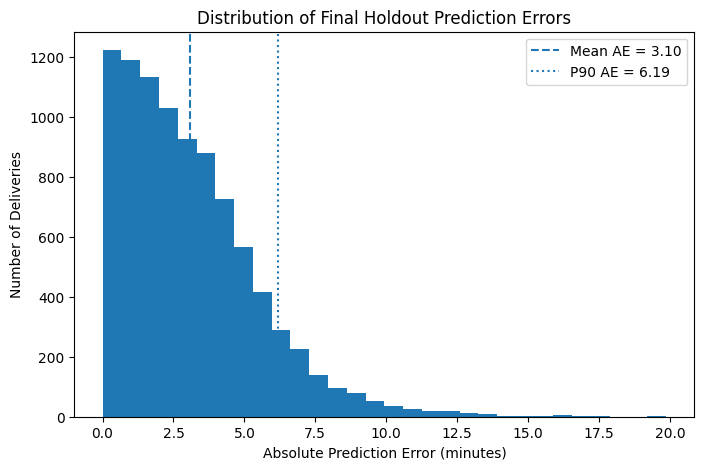

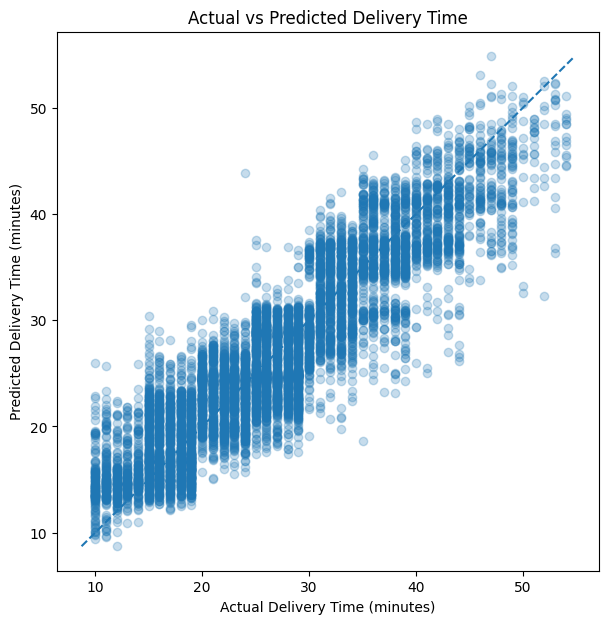

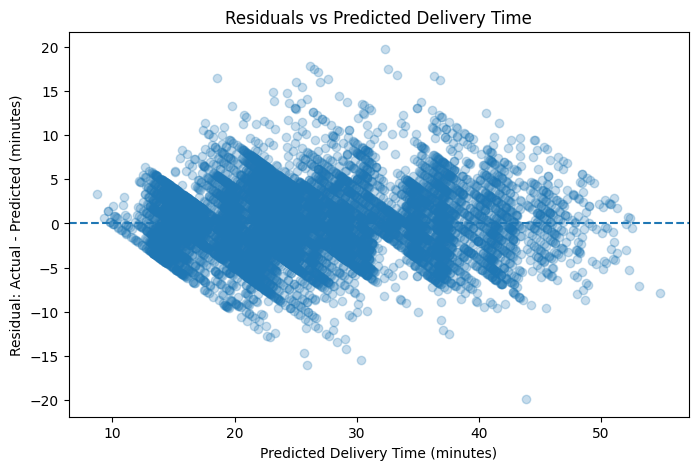

Final error-analysis checks passed.


In [173]:
# ==================================================
# 11. DOMAIN-BASED ERROR ANALYSIS
# ==================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# --------------------------------------------------
# 11.1 Build the final error-analysis dataframe
# --------------------------------------------------

error_analysis = (
    X_test_fe
    .reset_index(drop=True)
    .copy()
)

error_analysis["actual_delivery_time"] = y_true
error_analysis["predicted_delivery_time"] = y_pred

# Residual:
# positive  -> model underestimated delivery time
# negative  -> model overestimated delivery time
error_analysis["residual"] = (
    error_analysis["actual_delivery_time"]
    - error_analysis["predicted_delivery_time"]
)

error_analysis["absolute_error"] = (
    error_analysis["residual"].abs()
)

error_analysis["underestimated"] = (
    error_analysis["predicted_delivery_time"]
    < error_analysis["actual_delivery_time"]
).astype(int)


# --------------------------------------------------
# 11.2 Clean categorical labels for reporting
# --------------------------------------------------

categorical_report_columns = [
    "weather_conditions",
    "road_traffic_density",
    "vehicle_condition",
    "order_type",
    "vehicle_type",
    "festival",
    "area_type",
    "order_day_of_week",
]

for column in categorical_report_columns:

    if column in error_analysis.columns:

        error_analysis[column] = (
            error_analysis[column]
            .astype("string")
            .fillna("__MISSING__")
        )


# multiple_deliveries is easier to interpret as groups
error_analysis["multiple_deliveries_group"] = (
    error_analysis["multiple_deliveries"]
    .astype("Int64")
    .astype("string")
    .fillna("__MISSING__")
)


# coordinate quality group
error_analysis["coordinate_status"] = np.where(
    error_analysis["coordinate_fixed"] == 1,
    "Coordinate issue/fix",
    "Original valid coordinates"
)


# --------------------------------------------------
# 11.3 Distance bands
# --------------------------------------------------
# Create distance thresholds using TRAINING data,
# then apply the same thresholds to the final holdout.

_, distance_bins = pd.qcut(
    X_train_fe["delivery_distance_km"].dropna(),
    q=5,
    retbins=True,
    duplicates="drop"
)

# Ensure all possible holdout values can be assigned
distance_bins[0] = -np.inf
distance_bins[-1] = np.inf

distance_labels = [
    f"Q{i + 1}"
    for i in range(len(distance_bins) - 1)
]

error_analysis["distance_band"] = pd.cut(
    error_analysis["delivery_distance_km"],
    bins=distance_bins,
    labels=distance_labels,
    include_lowest=True
)

error_analysis["distance_band"] = (
    error_analysis["distance_band"]
    .astype("string")
    .fillna("__MISSING__")
)


# --------------------------------------------------
# 11.4 Actual delivery-time bands
# --------------------------------------------------
# Used only for diagnostic analysis.
# This helps evaluate whether the model has more
# difficulty with very short or very long deliveries.

error_analysis["actual_time_band"] = pd.cut(
    error_analysis["actual_delivery_time"],
    bins=[
        0,
        20,
        30,
        40,
        50,
        np.inf
    ],
    labels=[
        "<=20 min",
        "21-30 min",
        "31-40 min",
        "41-50 min",
        ">50 min"
    ],
    include_lowest=True
)


# ==================================================
# 11.5 FUNCTION FOR SEGMENT-BASED ERROR METRICS
# ==================================================

def segment_error_report(
    df,
    segment_column,
    min_group_size=20
):
    """
    Calculate model performance for each category
    of a selected operational feature.
    """

    rows = []

    for group_name, group in df.groupby(
        segment_column,
        dropna=False,
        observed=True
    ):

        n = len(group)

        if n < min_group_size:
            continue

        actual = group["actual_delivery_time"].to_numpy()
        predicted = group["predicted_delivery_time"].to_numpy()

        residual = actual - predicted
        absolute_error = np.abs(residual)

        rows.append(
            {
                "Group": group_name,

                "N": n,

                "MAE": absolute_error.mean(),

                "RMSE": np.sqrt(
                    np.mean(
                        residual ** 2
                    )
                ),

                "Median AE": np.median(
                    absolute_error
                ),

                "P90 AE": np.percentile(
                    absolute_error,
                    90
                ),

                "Within ±5 min (%)": (
                    np.mean(
                        absolute_error <= 5
                    )
                    * 100
                ),

                "Within ±10 min (%)": (
                    np.mean(
                        absolute_error <= 10
                    )
                    * 100
                ),

                # Positive:
                # actual > prediction
                # therefore model underestimated
                "Mean Residual": residual.mean(),

                "Underestimation (%)": (
                    np.mean(
                        predicted < actual
                    )
                    * 100
                )
            }
        )

    result = pd.DataFrame(rows)

    if len(result) == 0:
        return result

    return (
        result
        .sort_values(
            "MAE",
            ascending=False
        )
        .reset_index(drop=True)
    )


# ==================================================
# 11.6 TRAFFIC ERROR ANALYSIS
# ==================================================

traffic_errors = segment_error_report(
    error_analysis,
    "road_traffic_density"
)

print("Performance by Road Traffic Density:")
display(
    traffic_errors.round(3)
)


# ==================================================
# 11.7 WEATHER ERROR ANALYSIS
# ==================================================

weather_errors = segment_error_report(
    error_analysis,
    "weather_conditions"
)

print("Performance by Weather Conditions:")
display(
    weather_errors.round(3)
)


# ==================================================
# 11.8 FESTIVAL ERROR ANALYSIS
# ==================================================

festival_errors = segment_error_report(
    error_analysis,
    "festival"
)

print("Performance by Festival Status:")
display(
    festival_errors.round(3)
)


# ==================================================
# 11.9 MULTIPLE DELIVERIES ERROR ANALYSIS
# ==================================================

multiple_delivery_errors = segment_error_report(
    error_analysis,
    "multiple_deliveries_group"
)

print("Performance by Number of Multiple Deliveries:")
display(
    multiple_delivery_errors.round(3)
)


# ==================================================
# 11.10 DISTANCE ERROR ANALYSIS
# ==================================================

distance_errors = segment_error_report(
    error_analysis,
    "distance_band"
)

print("Performance by Delivery Distance:")
display(
    distance_errors.round(3)
)


# ==================================================
# 11.11 AREA TYPE ERROR ANALYSIS
# ==================================================

area_errors = segment_error_report(
    error_analysis,
    "area_type"
)

print("Performance by Area Type:")
display(
    area_errors.round(3)
)


# ==================================================
# 11.12 VEHICLE TYPE ERROR ANALYSIS
# ==================================================

vehicle_errors = segment_error_report(
    error_analysis,
    "vehicle_type"
)

print("Performance by Vehicle Type:")
display(
    vehicle_errors.round(3)
)


# ==================================================
# 11.13 COORDINATE QUALITY ERROR ANALYSIS
# ==================================================

coordinate_errors = segment_error_report(
    error_analysis,
    "coordinate_status"
)

print("Performance by Coordinate Quality:")
display(
    coordinate_errors.round(3)
)


# ==================================================
# 11.14 PERFORMANCE BY ACTUAL DELIVERY TIME
# ==================================================

actual_time_errors = segment_error_report(
    error_analysis,
    "actual_time_band"
)

print("Performance by Actual Delivery-Time Range:")
display(
    actual_time_errors.round(3)
)


# ==================================================
# 11.15 SUMMARY TABLE OF DIFFICULT SEGMENTS
# ==================================================

segment_tables = {
    "Traffic": traffic_errors,
    "Weather": weather_errors,
    "Festival": festival_errors,
    "Multiple Deliveries": multiple_delivery_errors,
    "Distance": distance_errors,
    "Area Type": area_errors,
    "Vehicle Type": vehicle_errors,
    "Coordinate Quality": coordinate_errors,
    "Actual Delivery Time": actual_time_errors,
}

difficult_segments = []

for feature_name, table in segment_tables.items():

    if table.empty:
        continue

    worst_group = (
        table
        .sort_values(
            "MAE",
            ascending=False
        )
        .iloc[0]
    )

    difficult_segments.append(
        {
            "Feature": feature_name,
            "Most Difficult Group": worst_group["Group"],
            "N": worst_group["N"],
            "MAE": worst_group["MAE"],
            "P90 AE": worst_group["P90 AE"],
            "Underestimation (%)": worst_group[
                "Underestimation (%)"
            ],
        }
    )


difficult_segments_df = (
    pd.DataFrame(
        difficult_segments
    )
    .sort_values(
        "MAE",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Most Difficult Segment within Each Feature:")
display(
    difficult_segments_df.round(3)
)


# ==================================================
# 11.16 WORST INDIVIDUAL PREDICTIONS WITH CONTEXT
# ==================================================

worst_prediction_columns = [
    "actual_delivery_time",
    "predicted_delivery_time",
    "absolute_error",
    "residual",
    "road_traffic_density",
    "weather_conditions",
    "festival",
    "multiple_deliveries_group",
    "area_type",
    "vehicle_type",
    "delivery_distance_km",
    "coordinate_status",
]

worst_predictions_with_context = (
    error_analysis[
        worst_prediction_columns
    ]
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(20)
)

print("Twenty Largest Holdout Errors:")
display(
    worst_predictions_with_context.round(3)
)


# ==================================================
# 11.17 ERROR DISTRIBUTION
# ==================================================

plt.figure(figsize=(8, 5))

plt.hist(
    error_analysis["absolute_error"],
    bins=30
)

plt.axvline(
    final_mae,
    linestyle="--",
    label=f"Mean AE = {final_mae:.2f}"
)

plt.axvline(
    p90_absolute_error,
    linestyle=":",
    label=f"P90 AE = {p90_absolute_error:.2f}"
)

plt.xlabel("Absolute Prediction Error (minutes)")
plt.ylabel("Number of Deliveries")
plt.title("Distribution of Final Holdout Prediction Errors")
plt.legend()

plt.show()


# ==================================================
# 11.18 ACTUAL VS PREDICTED
# ==================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    error_analysis["actual_delivery_time"],
    error_analysis["predicted_delivery_time"],
    alpha=0.25
)

plot_min = min(
    error_analysis["actual_delivery_time"].min(),
    error_analysis["predicted_delivery_time"].min()
)

plot_max = max(
    error_analysis["actual_delivery_time"].max(),
    error_analysis["predicted_delivery_time"].max()
)

plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--"
)

plt.xlabel("Actual Delivery Time (minutes)")
plt.ylabel("Predicted Delivery Time (minutes)")
plt.title("Actual vs Predicted Delivery Time")

plt.show()


# ==================================================
# 11.19 RESIDUALS VS PREDICTED VALUES
# ==================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    error_analysis["predicted_delivery_time"],
    error_analysis["residual"],
    alpha=0.25
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Delivery Time (minutes)")
plt.ylabel("Residual: Actual - Predicted (minutes)")
plt.title("Residuals vs Predicted Delivery Time")

plt.show()


# ==================================================
# 11.20 FINAL SANITY CHECK
# ==================================================

assert len(error_analysis) == len(y_test)

assert np.isclose(
    error_analysis["absolute_error"].mean(),
    final_mae
)

print("Final error-analysis checks passed.")

The domain-based error analysis shows that the final CatBoost model performs consistently across most operational conditions, although several specific situations remain more difficult to predict.

Traffic conditions show a clear relationship with prediction accuracy. Deliveries under low traffic conditions produced the lowest error, with an MAE of approximately 2.62 minutes, whereas jam and high-traffic conditions resulted in higher errors of approximately 3.43 and 3.32 minutes, respectively. The largest error occurred when traffic information was missing, where MAE increased to approximately 5.95 minutes. A similar pattern was observed for weather information. Missing weather observations produced an MAE of approximately 5.87 minutes, substantially higher than the errors observed for the recorded weather categories. These results indicate that missing contextual information can substantially reduce prediction reliability.

Delivery distance also influenced model performance. Prediction error generally increased across the distance quantiles, from approximately 2.75 minutes in the shortest-distance group to 3.31 minutes in the longest-distance group. Deliveries for which distance could not be calculated produced an even higher MAE of approximately 3.76 minutes. This result is consistent with the coordinate-quality analysis: observations associated with coordinate problems had an MAE of 3.76 minutes, compared with approximately 3.04 minutes for observations with valid original coordinates. Geographic data quality therefore appears to be an important limitation of the available dataset.

The model performed relatively consistently across most area and vehicle categories. Among the sufficiently represented vehicle groups, motorcycle deliveries had the highest MAE at approximately 3.18 minutes, although the difference from scooters and electric scooters was relatively small. Similarly, Metropolitan and Urban deliveries showed comparable performance. The Semi-Urban group showed a lower MAE, but this group contained only 31 observations and should therefore be interpreted cautiously.

Festival and multiple-delivery groups did not produce the expected deterioration in predictive accuracy. Festival deliveries showed a lower MAE than non-festival deliveries, while deliveries associated with two or three simultaneous deliveries also showed relatively low prediction errors. However, these groups contained substantially fewer observations than the dominant categories. Consequently, these findings should not be interpreted as evidence that festivals or multiple deliveries make delivery operations easier; rather, they indicate that the trained model was able to predict the available observations in these smaller groups reasonably well.

The strongest systematic error pattern was associated with the actual duration of the delivery. Deliveries longer than 50 minutes had an MAE of approximately 5.87 minutes, and approximately 96% of these cases were underestimated. Deliveries between 41 and 50 minutes also showed elevated error and a strong tendency toward underestimation. In contrast, deliveries of 20 minutes or less tended to be overestimated. This pattern indicates regression toward the center of the target distribution: unusually long deliveries tend to be predicted as shorter than they actually are, while unusually short deliveries tend to be predicted as longer.

Inspection of the largest individual errors supports these findings. Several large underestimations occurred for deliveries with actual durations above 40–50 minutes, while some of the largest overestimations occurred for unusually short deliveries. Missing traffic, weather, distance, or coordinate information was also present in several high-error observations. Therefore, the remaining large errors appear to be associated primarily with extreme delivery durations and incomplete contextual or geographic information rather than with a general directional bias in the model.

Overall, the segment analysis suggests that the model provides stable predictions for typical delivery conditions but becomes less reliable when important contextual information is missing, geographic information is unavailable, delivery distances are longer, or the true delivery duration is unusually extreme. These findings are treated as diagnostic limitations of the final model and are not used for additional tuning because the holdout set has already been used for final evaluation.


#Conclusion
This project developed and evaluated a complete machine learning workflow for predicting food delivery time. The workflow included data-quality auditing, exploratory data analysis, feature engineering, leakage-aware preprocessing, baseline modeling, cross-validation, nonlinear ensemble models, hyperparameter optimization, final holdout evaluation, and domain-based error analysis.

The initial baseline results demonstrated that the available features contained substantial predictive information. Linear Regression and Ridge Regression reduced cross-validation MAE from approximately 7.59 minutes for the median Dummy Regressor to approximately 4.72 minutes. However, nonlinear tree-based methods produced a further substantial improvement, indicating that food delivery duration depends on nonlinear relationships and interactions that simple linear models cannot fully represent.

Among the nonlinear models, Random Forest, LightGBM, XGBoost, and CatBoost all achieved strong performance. CatBoost produced the best baseline cross-validation result and remained the strongest model after hyperparameter optimization. The tuned CatBoost model achieved a five-fold cross-validation MAE of approximately 3.13 minutes and was therefore selected as the final model. Importantly, model selection and hyperparameter optimization were performed without using the final holdout set.

When the selected model was retrained using the complete training dataset and evaluated once on the previously untouched holdout set, it achieved an MAE of 3.10 minutes, an RMSE of 3.92 minutes, an R² of approximately 0.82, and a MAPE of approximately 13.37%. The median absolute prediction error was approximately 2.64 minutes, while the 90th percentile absolute error was approximately 6.19 minutes. Approximately 81.7% of predictions were within ±5 minutes of the true delivery time, and approximately 98.5% were within ±10 minutes.

The final holdout MAE of 3.10 minutes was extremely close to the tuned cross-validation MAE of 3.13 minutes. This agreement indicates that the cross-validation procedure provided a reliable estimate of out-of-sample performance and that substantial overfitting to the validation folds was not evident. In addition, the mean signed error was close to zero and the model underestimated approximately 49% of observations, suggesting that there was little overall systematic bias toward either underprediction or overprediction.

The domain-based error analysis nevertheless identified several important limitations. Predictions became less accurate when traffic or weather information was missing and when geographic coordinates were unreliable or delivery distance could not be calculated. Prediction error also tended to increase for longer delivery distances. Most importantly, the model showed greater difficulty with extreme delivery durations. Deliveries exceeding 50 minutes were frequently underestimated, whereas very short deliveries tended to be overestimated. This behavior suggests that the model partially regresses extreme cases toward more common delivery durations.

Overall, the results demonstrate that gradient-boosting methods are well suited to this food-delivery-time prediction problem and that the tuned CatBoost model provides accurate and stable predictions for the majority of deliveries. At the same time, the analysis shows that prediction reliability depends on the completeness of operational and geographic information and decreases for unusually extreme delivery cases. Future work could therefore focus on improving location data quality, incorporating richer route and real-time traffic information, evaluating temporal generalization on future delivery periods, and developing prediction intervals to communicate uncertainty for difficult deliveries.
